In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import style
from decimal import Decimal
import uproot
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split
import warnings
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, roc_auc_score

import mplhep
import os

import shap

/home/shreecheta/.local/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(shap.__version__)

0.44.1


In [3]:
plt.rcParams["figure.figsize"] = (7,5)
plt.rc('xtick', direction='in')
plt.rc('ytick', direction='in')
plt.rc('font', family='serif')

s_size = 5
latex_size = 20
scat = "scatter"
alp = 0.3
mpl.rcParams['axes.xmargin'] = 0
mpl.rcParams["xtick.minor.visible"] =  True
mpl.rcParams["ytick.minor.visible"] =  True
mpl.rcParams['xtick.major.size'] = 10
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['xtick.minor.size'] = 5
mpl.rcParams['xtick.minor.width'] = 1.0

mpl.rcParams['ytick.minor.size'] = 5
mpl.rcParams['ytick.minor.width'] = 1.0
mpl.rcParams['ytick.major.size'] = 10
mpl.rcParams['ytick.major.width'] = 1.5

mpl.rcParams.update({"axes.grid" : True, "grid.color": "black","grid.alpha": "0.1" })
mpl.rcParams['font.size'] = 16
plt.rc('legend', loc='best',fancybox=True,markerscale=2) 

In [4]:
import ROOT
from ROOT import gROOT, gStyle, TFile, TTree, TH1F, TF1, TMath, TCanvas

Welcome to JupyROOT 6.24/02


In [5]:
def plot_branch(bname, Fname, **kwargs):
    """
    Plot multiple branches from ROOT files using mplhep
    
    Parameters:
    -----------
    bname : str or list
        Branch name(s) to plot
    Fname : str or list  
        ROOT file path(s) or location(s) - should match length of bname
        Can be full paths like '/path/to/file.root' or just filenames
    **kwargs : dict
        rebin : int or list, default 1
            Rebinning factor(s)
        xmin : float or list, optional
            Minimum x-axis value(s)
        xmax : float or list, optional  
            Maximum x-axis value(s)
        bins : int, default 50
            Number of bins for histogram
        color : str or list, default matplotlib colors
            Color(s) of the histogram(s)
        lines : str or list, default ['-']
            Line style(s) for histogram(s)
        legs : str or list, optional
            Legend label(s)
        ylabel : str, default 'Events'
            Y-axis label
        xlabel : str, optional
            X-axis label (defaults to first branch name)
        normalize : bool, default False
            Whether to normalize histograms to unit area
        scale_factor : float or list, default 1.0
            Scaling factor(s) for histogram(s)
        figsize : tuple, default (10, 6)
            Figure size
        tree_name : str, optional
            Specific tree name (if not provided, uses first tree)
        fill : bool, default False
            Whether to fill histograms with color
        hatch : str or list, optional
            Hatch pattern(s): '/', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*'
        alpha : float or list, default 0.7
            Transparency for filled histograms
        edgecolor : str or list, optional
            Edge color for histograms (default: same as fill color)
    
    Returns:
    --------
    matplotlib.figure.Figure
        The created figure
    """
    
    # Convert single values to lists
    if isinstance(bname, str):
        bname = [bname]
    if isinstance(Fname, str):
        Fname = [Fname]
    
    # Check that bname and Fname have same length
    if len(bname) != len(Fname):
        raise ValueError(f"Length of bname ({len(bname)}) must match length of Fname ({len(Fname)})")
    
    n_plots = len(bname)
    
    # Extract and expand keyword arguments to match number of plots
    def expand_param(param, default_val):
        if param is None:
            return [default_val] * n_plots
        if not isinstance(param, list):
            return [param] * n_plots
        if len(param) != n_plots:
            raise ValueError(f"Length of {param} must match number of plots ({n_plots})")
        return param
    
    rebin = expand_param(kwargs.get('rebin'), 1)
    xmin = expand_param(kwargs.get('xmin'), None)
    xmax = expand_param(kwargs.get('xmax'), None)
    bins = kwargs.get('bins', 50)
    
    # Default colors using matplotlib color cycle
    default_colors = plt.cm.tab10.colors[:n_plots] if n_plots <= 10 else plt.cm.tab10.colors * ((n_plots // 10) + 1)
    color = expand_param(kwargs.get('color'), default_colors[0])
    if kwargs.get('color') is None:
        color = default_colors[:n_plots]
    
    lines = expand_param(kwargs.get('lines', ['-']), '-')
    legs = expand_param(kwargs.get('legs'), f'Histogram')
    if kwargs.get('legs') is None:
        legs = [f'{bname[i]}' for i in range(n_plots)]
    
    ylabel = kwargs.get('ylabel', 'A.U.')
    xlabel = kwargs.get('xlabel', bname[0])
    normalize = kwargs.get('normalize', True)
    scale_factor = expand_param(kwargs.get('scale_factor'), 1.0)
    tree_name = kwargs.get('tree_name', None)
    
    # New parameters for filling and patterns
    fill = kwargs.get('fill', False)
    hatch = expand_param(kwargs.get('hatch'), None)
    alpha = expand_param(kwargs.get('alpha'), 0.7)
    edgecolor = expand_param(kwargs.get('edgecolor'), None)
    
    # Plot each distribution
    for idx in range(n_plots):
        # Resolve file path - can be full path or just filename
        file_path = Fname[idx]
        
        # Check if file exists
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"File not found: {file_path}")
        
        # Open ROOT file and read branch data
        with uproot.open(file_path) as file:
            # Get the tree
            if tree_name is None:
                tree_key = list(file.keys())[0]
            else:
                tree_key = tree_name
            tree = file[tree_key]
            
            # Read branch data
            data = tree[bname[idx]].array(library='np')
        
        # Apply range cuts if specified
        if xmin[idx] is not None:
            data = data[data >= xmin[idx]]
        if xmax[idx] is not None:
            data = data[data <= xmax[idx]]
        
        # Determine histogram range
        hist_xmin = xmin[idx] if xmin[idx] is not None else np.min(data)
        hist_xmax = xmax[idx] if xmax[idx] is not None else np.max(data)
        
        # Create histogram
        bin_edges = np.linspace(hist_xmin, hist_xmax, bins + 1)
        
        # Apply rebinning by reducing number of bins
        if rebin[idx] > 1:
            new_bins = max(1, bins // rebin[idx])
            bin_edges = np.linspace(hist_xmin, hist_xmax, new_bins + 1)
        
        # Calculate histogram
        bin_contents, bin_edges = np.histogram(data, bins=bin_edges)
        
        # Apply scaling
        if normalize:
            if np.sum(bin_contents) > 0:
                bin_contents = bin_contents.astype(float) / np.sum(bin_contents)
        elif scale_factor[idx] != 1.0:
            bin_contents = bin_contents * scale_factor[idx]
        
        # Determine edge color (default to darker version of fill color)
        edge_col = edgecolor[idx] if edgecolor[idx] is not None else color[idx]
        
        # Plot using mplhep with fill and hatch options
        if fill:
            mplhep.histplot(
                bin_contents,
                bin_edges, 
                label=legs[idx],
                color=color[idx],
                linestyle=lines[idx],
                histtype='fill',
                alpha=alpha[idx],
                edgecolor=edge_col,
                hatch=hatch[idx]
            )
        else:
            mplhep.histplot(
                bin_contents,
                bin_edges, 
                label=legs[idx],
                color=color[idx],
                linestyle=lines[idx]
            )
    
    # Styling
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    
    # Dynamically adjust legend columns based on number of entries
    plt.legend(
        loc='best', 
        fontsize=11, 
        ncol=max(1, len(legs) // 4 + (1 if len(legs) % 3 else 0))
    )
    
    plt.tight_layout()
        
    return plt

In [6]:
def plot_branch(bname, Fname, **kwargs):
    """
    Plot multiple branches from ROOT files using mplhep
    
    Parameters:
    -----------
    bname : str or list
        Branch name(s) to plot
    Fname : str or list  
        ROOT file path(s) or location(s) - should match length of bname
        Can be full paths like '/path/to/file.root' or just filenames
    **kwargs : dict
        rebin : int or list, default 1
            Rebinning factor(s)
        xmin : float or list, optional
            Minimum x-axis value(s)
        xmax : float or list, optional  
            Maximum x-axis value(s)
        bins : int, default 50
            Number of bins for histogram
        color : str or list, default matplotlib colors
            Color(s) of the histogram(s)
        lines : str or list, default ['-']
            Line style(s) for histogram(s)
        legs : str or list, optional
            Legend label(s)
        ylabel : str, default 'Events'
            Y-axis label
        xlabel : str, optional
            X-axis label (defaults to first branch name)
        normalize : bool, default False
            Whether to normalize histograms to unit area
        scale_factor : float or list, default 1.0
            Scaling factor(s) for histogram(s)
        figsize : tuple, default (10, 6)
            Figure size
        tree_name : str, optional
            Specific tree name (if not provided, uses first tree)
    
    Returns:
    --------
    matplotlib.figure.Figure
        The created figure
    """
    
    # Convert single values to lists
    if isinstance(bname, str):
        bname = [bname]
    if isinstance(Fname, str):
        Fname = [Fname]
    
    # Check that bname and Fname have same length
    if len(bname) != len(Fname):
        raise ValueError(f"Length of bname ({len(bname)}) must match length of Fname ({len(Fname)})")
    
    n_plots = len(bname)
    
    # Extract and expand keyword arguments to match number of plots
    def expand_param(param, default_val):
        if param is None:
            return [default_val] * n_plots
        if not isinstance(param, list):
            return [param] * n_plots
        if len(param) != n_plots:
            raise ValueError(f"Length of {param} must match number of plots ({n_plots})")
        return param
    
    rebin = expand_param(kwargs.get('rebin'), 1)
    xmin = expand_param(kwargs.get('xmin'), None)
    xmax = expand_param(kwargs.get('xmax'), None)
    bins = kwargs.get('bins', 50)
    
    # Default colors using matplotlib color cycle
    default_colors = plt.cm.tab10.colors[:n_plots] if n_plots <= 10 else plt.cm.tab10.colors * ((n_plots // 10) + 1)
    color = expand_param(kwargs.get('color'), default_colors[0])
    if kwargs.get('color') is None:
        color = default_colors[:n_plots]
    
    lines = expand_param(kwargs.get('lines', ['-']), '-')
    legs = expand_param(kwargs.get('legs'), f'Histogram')
    if kwargs.get('legs') is None:
        legs = [f'{bname[i]}' for i in range(n_plots)]
    
    ylabel = kwargs.get('ylabel', 'A.U.')
    xlabel = kwargs.get('xlabel', bname[0])
    normalize = kwargs.get('normalize', True)
    scale_factor = expand_param(kwargs.get('scale_factor'), 1.0)
    tree_name = kwargs.get('tree_name', None)
    
    # Plot each distribution
    for idx in range(n_plots):
        # Resolve file path - can be full path or just filename
        file_path = Fname[idx]
        
        # Check if file exists
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"File not found: {file_path}")
        
        # Open ROOT file and read branch data
        with uproot.open(file_path) as file:
            # Get the tree
            if tree_name is None:
                tree_key = list(file.keys())[0]
            else:
                tree_key = tree_name
            tree = file[tree_key]
            
            # Read branch data
            data = tree[bname[idx]].array(library='np')
        
        # Apply range cuts if specified
        if xmin[idx] is not None:
            data = data[data >= xmin[idx]]
        if xmax[idx] is not None:
            data = data[data <= xmax[idx]]
        
        # Determine histogram range
        hist_xmin = xmin[idx] if xmin[idx] is not None else np.min(data)
        hist_xmax = xmax[idx] if xmax[idx] is not None else np.max(data)
        
        # Create histogram
        bin_edges = np.linspace(hist_xmin, hist_xmax, bins + 1)
        
        # Apply rebinning by reducing number of bins
        if rebin[idx] > 1:
            new_bins = max(1, bins // rebin[idx])
            bin_edges = np.linspace(hist_xmin, hist_xmax, new_bins + 1)
        
        # Calculate histogram
        bin_contents, bin_edges = np.histogram(data, bins=bin_edges)
        
        # Apply scaling
        if normalize:
            if np.sum(bin_contents) > 0:
                bin_contents = bin_contents.astype(float) / np.sum(bin_contents)
        elif scale_factor[idx] != 1.0:
            bin_contents = bin_contents * scale_factor[idx]
        
        # Plot using mplhep
        mplhep.histplot(
            bin_contents,
            bin_edges, 
            label=legs[idx],
            color=color[idx],
            linestyle=lines[idx],
            linewidth=2
        )
    
    # Styling
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    
    # Dynamically adjust legend columns based on number of entries
    plt.legend(
        loc='best', 
        fontsize=11, 
        ncol=max(1, len(legs) // 4 + (1 if len(legs) % 3 else 0))
    )
    
    plt.tight_layout()
        
    return plt

In [7]:
root_file_ALP_Z_125 = "/data/SOM_Test/ALP_test/OutputFile_ALP_Z_125_Delphes.root"
root_file_ALP_Z_25 = "/data/SOM_Test/ALP_test/OutputFile_ALP_Z_25_Delphes.root"
root_file_H_Z_125 = "/data/SOM_Test/ALP_test/OutputFile_Higgs_Z_125_Delphes.root"

tree = "Tree"  # change if needed

f = ROOT.TFile.Open(root_file_ALP_Z_125)
t = f.Get(tree)

print("Branches in tree:", tree)
for br in t.GetListOfBranches():
    print(br.GetName())

Branches in tree: Tree
Total_Events
Z_reco_pt
LepP_pt
LepM_pt
MET_et
Dphi_LepP_LepM
Deta_LepP_LepM
Dphi_Z_Diphoton
Deta_Z_Diphoton
LP
Frac_energy_diff
Cos_theta_star
Phi_star


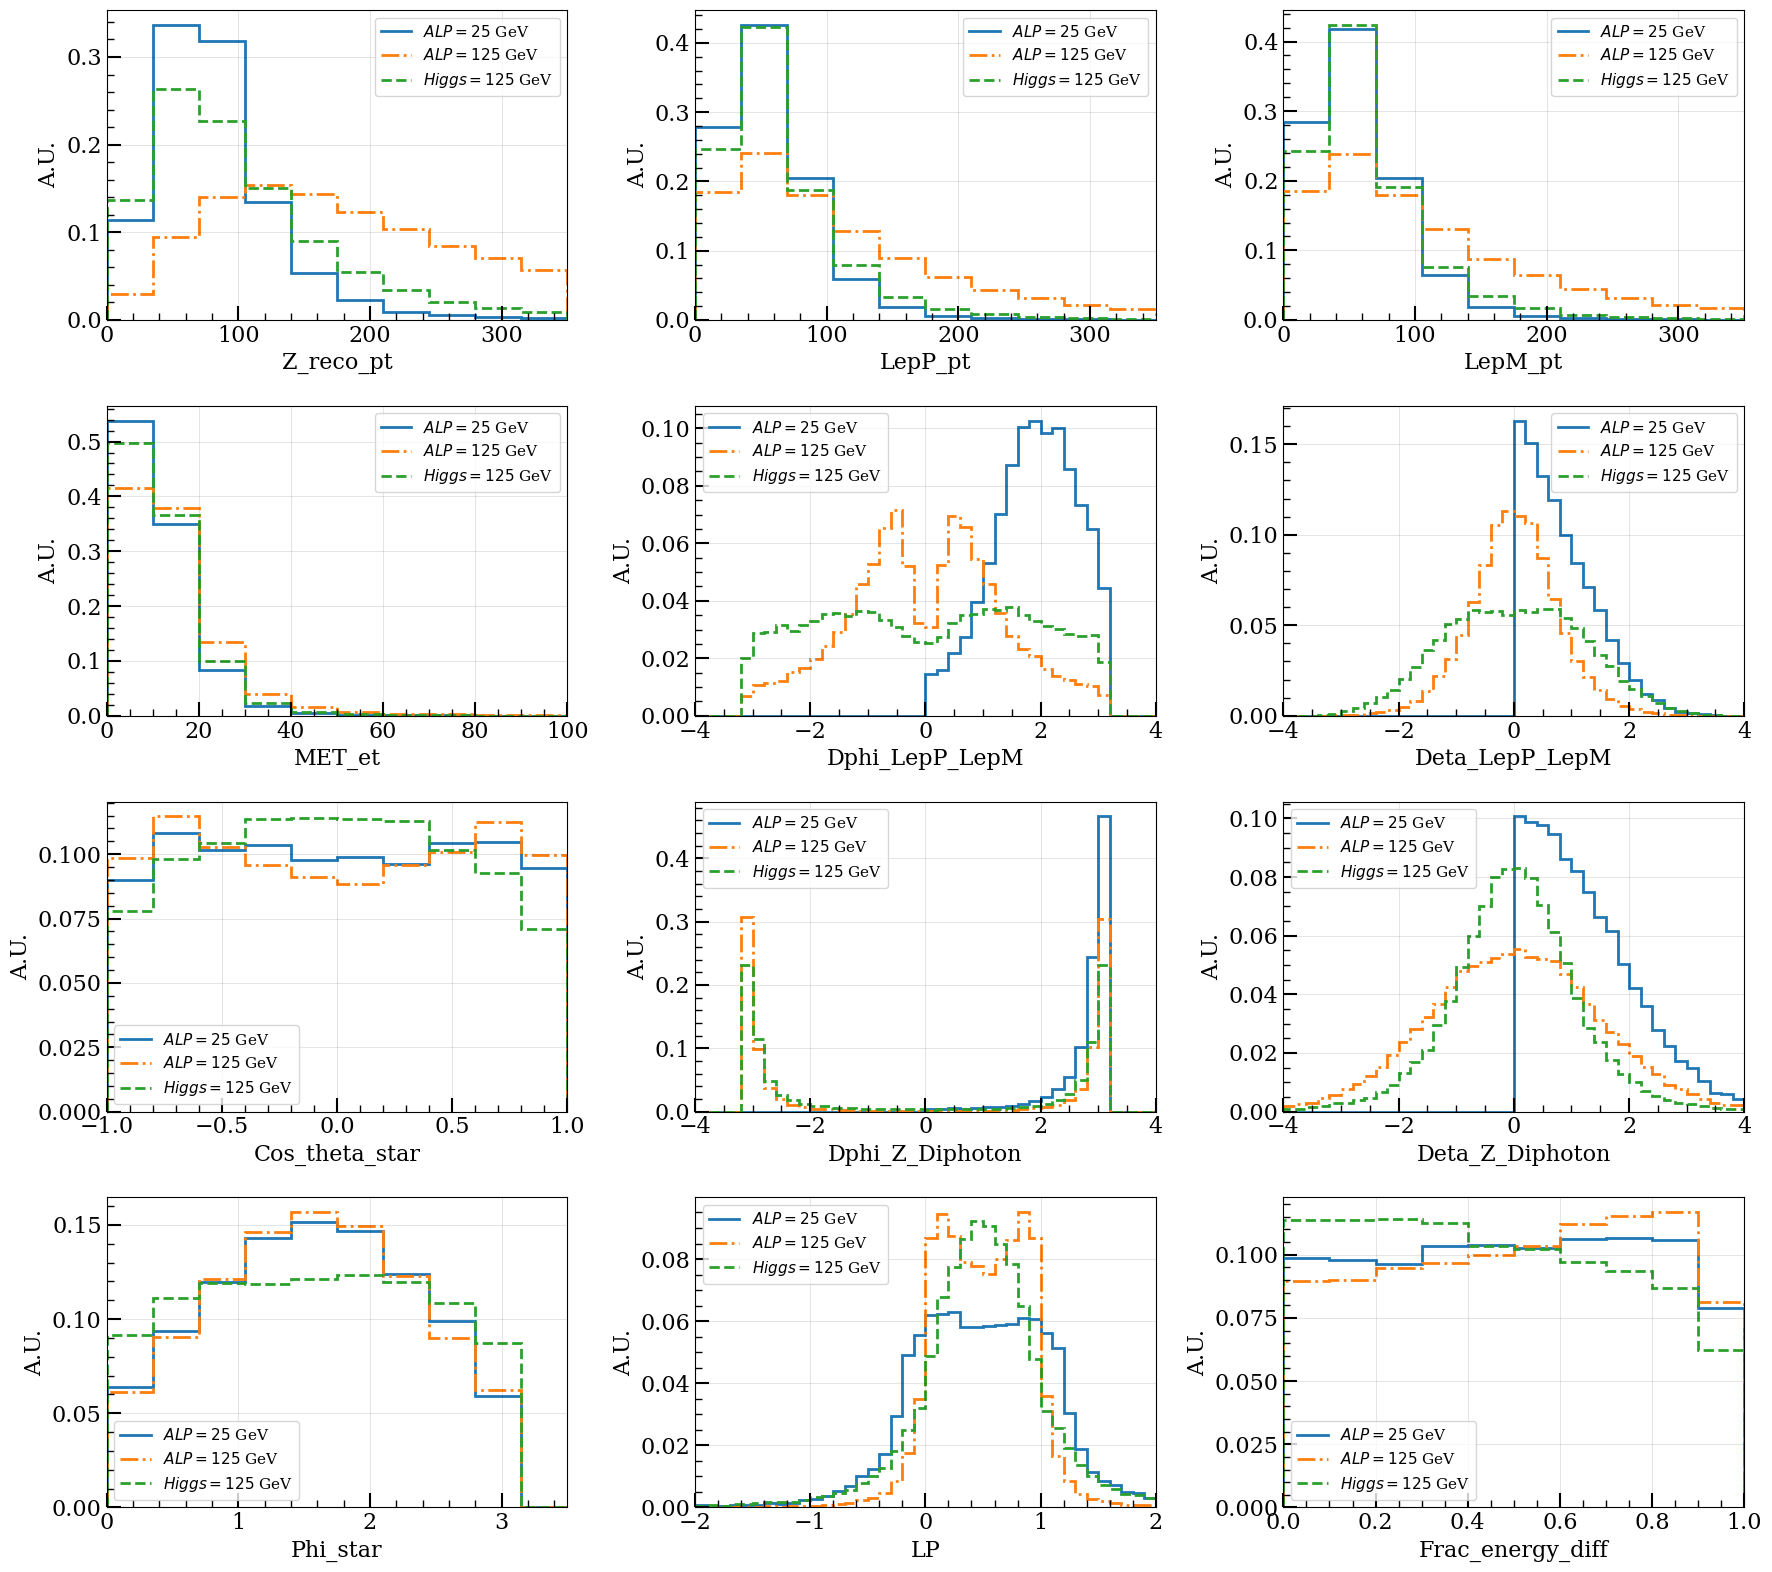

In [8]:
# Create a figure with multiple subplots
fig, axsom1 = plt.subplots(4, 3, figsize=(18, 16))


plt.sca(axsom1[0,0])
plot_branch(
    bname=['Z_reco_pt','Z_reco_pt', 'Z_reco_pt'],
    Fname=[root_file_ALP_Z_25, root_file_ALP_Z_125, root_file_H_Z_125],
    rebin=[1,1,1], 
    xmin=[0,0,0], 
    xmax=[350,350,350],
    bins=10,
    cols = ['red', 'cyan', 'green'],
    lines=['-','-.','--'],
    legs=[r"$ALP=25$ GeV", r"$ALP=125$ GeV", r"$Higgs=125$ GeV"])

plt.sca(axsom1[0,1])
plot_branch(
    bname=['LepP_pt','LepP_pt', 'LepP_pt'],
    Fname=[root_file_ALP_Z_25, root_file_ALP_Z_125, root_file_H_Z_125],
    rebin=[1,1,1], 
    xmin=[0,0,0], 
    xmax=[350,350,350],
    bins=10,
    cols = ['red', 'cyan', 'green'],
    lines=['-','-.','--'],
    legs=[r"$ALP=25$ GeV", r"$ALP=125$ GeV", r"$Higgs=125$ GeV"])

plt.sca(axsom1[0,2])
plot_branch(
    bname=['LepM_pt','LepM_pt', 'LepM_pt'],
    Fname=[root_file_ALP_Z_25, root_file_ALP_Z_125, root_file_H_Z_125],
    rebin=[1,1,1], 
    xmin=[0,0,0], 
    xmax=[350,350,350],
    bins=10,
    cols = ['red', 'cyan', 'green'],
    lines=['-','-.','--'],
    legs=[r"$ALP=25$ GeV", r"$ALP=125$ GeV", r"$Higgs=125$ GeV"])



plt.sca(axsom1[1,0])
plot_branch(
    bname=['MET_et','MET_et', 'MET_et'],
    Fname=[root_file_ALP_Z_25, root_file_ALP_Z_125, root_file_H_Z_125],
    rebin=[1,1,1], 
    xmin=[0,0,0], 
    xmax=[100,100,100],
    bins=10,
    cols = ['red', 'cyan', 'green'],
    lines=['-','-.','--'],
    legs=[r"$ALP=25$ GeV", r"$ALP=125$ GeV", r"$Higgs=125$ GeV"])

plt.sca(axsom1[1,1])
plot_branch(
    bname=['Dphi_LepP_LepM','Dphi_LepP_LepM', 'Dphi_LepP_LepM'],
    Fname=[root_file_ALP_Z_25, root_file_ALP_Z_125, root_file_H_Z_125],
    rebin=[1,1,1], 
    xmin=[-4,-4,-4], 
    xmax=[4,4,4],
    bins=40,
    cols = ['red', 'cyan', 'green'],
    lines=['-','-.','--'],
    legs=[r"$ALP=25$ GeV", r"$ALP=125$ GeV", r"$Higgs=125$ GeV"])

plt.sca(axsom1[1,2])
plot_branch(
    bname=['Deta_LepP_LepM','Deta_LepP_LepM', 'Deta_LepP_LepM'],
    Fname=[root_file_ALP_Z_25, root_file_ALP_Z_125, root_file_H_Z_125],
    rebin=[1,1,1], 
    xmin=[-4,-4,-4], 
    xmax=[4,4,4],
    bins=40,
    cols = ['red', 'cyan', 'green'],
    lines=['-','-.','--'],
    legs=[r"$ALP=25$ GeV", r"$ALP=125$ GeV", r"$Higgs=125$ GeV"])

plt.sca(axsom1[2,0])
plot_branch(
    bname=['Cos_theta_star','Cos_theta_star', 'Cos_theta_star'],
    Fname=[root_file_ALP_Z_25, root_file_ALP_Z_125, root_file_H_Z_125],
    rebin=[1,1,1], 
    xmin=[-1,-1,-1], 
    xmax=[1,1,1],
    bins=10,
    cols = ['red', 'cyan', 'green'],
    lines=['-','-.','--'],
    legs=[r"$ALP=25$ GeV", r"$ALP=125$ GeV", r"$Higgs=125$ GeV"])

plt.sca(axsom1[2,1])
plot_branch(
    bname=['Dphi_Z_Diphoton','Dphi_Z_Diphoton', 'Dphi_Z_Diphoton'],
    Fname=[root_file_ALP_Z_25, root_file_ALP_Z_125, root_file_H_Z_125],
    rebin=[1,1,1], 
    xmin=[-4,-4,-4], 
    xmax=[4,4,4],
    bins=40,
    cols = ['red', 'cyan', 'green'],
    lines=['-','-.','--'],
    legs=[r"$ALP=25$ GeV", r"$ALP=125$ GeV", r"$Higgs=125$ GeV"])

plt.sca(axsom1[2,2])
plot_branch(
    bname=['Deta_Z_Diphoton','Deta_Z_Diphoton', 'Deta_Z_Diphoton'],
    Fname=[root_file_ALP_Z_25, root_file_ALP_Z_125, root_file_H_Z_125],
    rebin=[1,1,1], 
    xmin=[-4,-4,-4], 
    xmax=[4,4,4],
    bins=40,
    cols = ['red', 'cyan', 'green'],
    lines=['-','-.','--'],
    legs=[r"$ALP=25$ GeV", r"$ALP=125$ GeV", r"$Higgs=125$ GeV"])

plt.sca(axsom1[3,0])
plot_branch(
    bname=['Phi_star','Phi_star', 'Phi_star'],
    Fname=[root_file_ALP_Z_25, root_file_ALP_Z_125, root_file_H_Z_125],
    rebin=[1,1,1], 
    xmin=[0,0,0], 
    xmax=[3.5,3.5,3.5],
    bins=10,
    cols = ['red', 'cyan', 'green'],
    lines=['-','-.','--'],
    legs=[r"$ALP=25$ GeV", r"$ALP=125$ GeV", r"$Higgs=125$ GeV"])


plt.sca(axsom1[3,1])
plot_branch(
    bname=['LP','LP', 'LP'],
    Fname=[root_file_ALP_Z_25, root_file_ALP_Z_125, root_file_H_Z_125],
    rebin=[1,1,1], 
    xmin=[-2,-2,-2], 
    xmax=[2,2,2],
    bins=40,
    cols = ['red', 'cyan', 'green'],
    lines=['-','-.','--'],
    legs=[r"$ALP=25$ GeV", r"$ALP=125$ GeV", r"$Higgs=125$ GeV"])

plt.sca(axsom1[3,2])
plot_branch(
    bname=['Frac_energy_diff', 'Frac_energy_diff', 'Frac_energy_diff'],
    Fname=[root_file_ALP_Z_25, root_file_ALP_Z_125, root_file_H_Z_125],
    rebin=[1,1,1], 
    xmin=[0,0,0,], 
    xmax=[1,1,1],
    bins=10,
    cols = ['red', 'cyan', 'green'],
    lines=['-','-.','--'],
    legs=[r"$ALP=25$ GeV", r"$ALP=125$ GeV", r"$Higgs=125$ GeV"])



plt.tight_layout()
plt.savefig("ALP_ANALYSIS/varibles_Z.png", dpi=300, bbox_inches="tight")
plt.show()


In [9]:
with uproot.open(root_file_ALP_Z_25) as file:
    tree = file["Tree"]
    print("Branches in the tree:")
    print(tree.keys())  # or list(tree.keys())

#read all branches into a DataFrame
with uproot.open(root_file_ALP_Z_25) as file:
    tree = file["Tree"]
    df_ALP_Z_25 = tree.arrays(library="pd")

with uproot.open(root_file_ALP_Z_125) as file:
    tree = file["Tree"]
    df_ALP_Z_125 = tree.arrays(library="pd")

with uproot.open(root_file_H_Z_125) as file:
    tree = file["Tree"]
    df_H_Z_125 = tree.arrays(library="pd")



Branches in the tree:
['Total_Events', 'Z_reco_pt', 'LepP_pt', 'LepM_pt', 'MET_et', 'Dphi_LepP_LepM', 'Deta_LepP_LepM', 'Dphi_Z_Diphoton', 'Deta_Z_Diphoton', 'LP', 'Frac_energy_diff', 'Cos_theta_star', 'Phi_star']


In [10]:
df_ALP_Z_25

,Total_Events,Z_reco_pt,LepP_pt,LepM_pt,MET_et,Dphi_LepP_LepM,Deta_LepP_LepM,Dphi_Z_Diphoton,Deta_Z_Diphoton,LP,Frac_energy_diff,Cos_theta_star,Phi_star
0,500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
485894,500000,35.781918,29.844814,65.382759,8.577292,3.047127,0.542617,2.817929,2.158467,-0.821593,0.605391,-0.605391,2.999893
485895,500000,35.781918,29.844814,65.382759,8.577292,3.047127,0.542617,2.817929,2.158467,-0.821593,0.605391,-0.605391,2.999893
485896,500000,35.781918,29.844814,65.382759,8.577292,3.047127,0.542617,2.817929,2.158467,-0.821593,0.605391,-0.605391,2.999893
485897,500000,35.781918,29.844814,65.382759,8.577292,3.047127,0.542617,2.817929,2.158467,-0.821593,0.605391,-0.605391,2.999893


In [11]:
'''
int_luminosity = 3000.0  # fb^-1 (e.g., 150 fb^-1 for Run 2)
BR_gamgam_p5 = 0.746
BR_gamgam_5 = 0.637
BR_gamgam_10 = 0.5988
BR_gamgam_30 = 0.8496
xs_signal_p5= (4.816751e-01) * 1000
xs_signal_5 = (4.810296e-01)*1000  #fb
xs_signal_10 = (4.790389e-01)*1000  #fb
xs_signal_30 = (4.617166e-01)*1000  #fb

xs_yyjj = 7.233 * 1000#fb
xs_yjj = 1084 * 1000 #fb
xs_QCD = 1.43 * pow(10,9) #fb 

# Cross-sections in fb (femtobarns)
cross_sections_BR = {
    1: xs_signal_p5 * BR_gamgam_p5 ,      # Signal A_p5 cross-section in fb
    2: xs_signal_5 * BR_gamgam_5,       # Signal A_5 cross-section in fb
    3: xs_signal_10 * BR_gamgam_10,       # Signal A_10 cross-section in fb
    4: xs_signal_30 * BR_gamgam_30,       # Signal A_30 cross-section in fb
    5: xs_yjj,   # Background yjj cross-section in fb
    6: xs_yyjj     # Background yyjj cross-section in fb
}

# Number of generated events (MC samples)
n_generated = {
    1: 100000,    # A_p5 generated events
    2: 100000,    # A_5 generated events
    3: 100000,    # A_10 generated events
    4: 100000,    # A_30 generated events
    5: 500000,    # yjj generated events
    6: 500000     # yyjj generated events
}

###Weights
def calculate_weight(label, cross_sections, n_generated, luminosity):
    
    sigma = cross_sections[label]  # Cross-section in fb
    n_gen = n_generated[label]     # Number of generated events
    
    weight = (sigma * luminosity) / n_gen
    return weight
'''
# Apply weights to each dataframe BEFORE concatenation
for df, label in [(df_ALP_Z_25, 1), (df_ALP_Z_125, 2), (df_H_Z_125, 3)]:
    df['label'] = label
    df['weight'] = 1 # for now
    #df['weight'] = calculate_weight(label, cross_sections_BR, n_generated, int_luminosity)






#print(root_file_ALP_Z_25.shape, root_file_ALP_Z_125.shape,  root_file_ALP_Z_25.shape)


df_all = pd.concat([df_ALP_Z_125, df_H_Z_125], ignore_index=True)
print("Weight Summary:")
print(df_all.groupby('label')['weight'].agg(['mean', 'sum', 'count']))


Weight Summary:
       mean     sum   count
label                      
2       1.0  480749  480749
3       1.0  483556  483556


In [12]:
df_all

,Total_Events,Z_reco_pt,LepP_pt,LepM_pt,MET_et,Dphi_LepP_LepM,Deta_LepP_LepM,Dphi_Z_Diphoton,Deta_Z_Diphoton,LP,Frac_energy_diff,Cos_theta_star,Phi_star,label,weight
0,500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2,1
1,500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2,1
2,500000,124.787315,104.469009,23.004976,14.890938,0.537487,-1.585414,-2.223252,0.590804,0.833439,0.449584,0.449584,0.247919,2,1
3,500000,53.808655,68.448944,25.782009,14.914910,2.339845,-0.786509,-2.153020,-1.730159,1.194306,0.715476,0.715476,2.216297,2,1
4,500000,53.808655,68.448944,25.782009,14.914910,2.339845,-0.786509,-2.153020,-1.730159,1.194306,0.715476,0.715476,2.216297,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
964300,500000,134.857269,22.922161,135.749313,8.639954,1.694327,-0.695415,1.601304,0.117099,0.007809,0.868810,-0.868810,1.586884,3,1
964301,500000,134.857269,22.922161,135.749313,8.639954,1.694327,-0.695415,1.601304,0.117099,0.007809,0.868810,-0.868810,1.586884,3,1
964302,500000,134.857269,22.922161,135.749313,8.639954,1.694327,-0.695415,1.601304,0.117099,0.007809,0.868810,-0.868810,1.586884,3,1
964303,500000,134.857269,22.922161,135.749313,8.639954,1.694327,-0.695415,1.601304,0.117099,0.007809,0.868810,-0.868810,1.586884,3,1


In [13]:
all_feat=  ['Z_reco_pt', 'LepP_pt', 'LepM_pt', 'MET_et', 'Dphi_LepP_LepM', 'Deta_LepP_LepM', 'Dphi_Z_Diphoton', 'Deta_Z_Diphoton', 'LP', 'Frac_energy_diff', 'Cos_theta_star', 'Phi_star']             
        
label_names = {1: 'ALP_Z=25 GeV', 2: 'ALP_Z=125 GeV', 3:'H_Z=125 GeV'}


In [14]:
#
df_all = df_all.dropna()
nan_rows = df_all[df_all.isna().any(axis=1)]
print(nan_rows)
print(len(df_all))

Empty DataFrame
Columns: [Total_Events, Z_reco_pt, LepP_pt, LepM_pt, MET_et, Dphi_LepP_LepM, Deta_LepP_LepM, Dphi_Z_Diphoton, Deta_Z_Diphoton, LP, Frac_energy_diff, Cos_theta_star, Phi_star, label, weight]
Index: []
964305


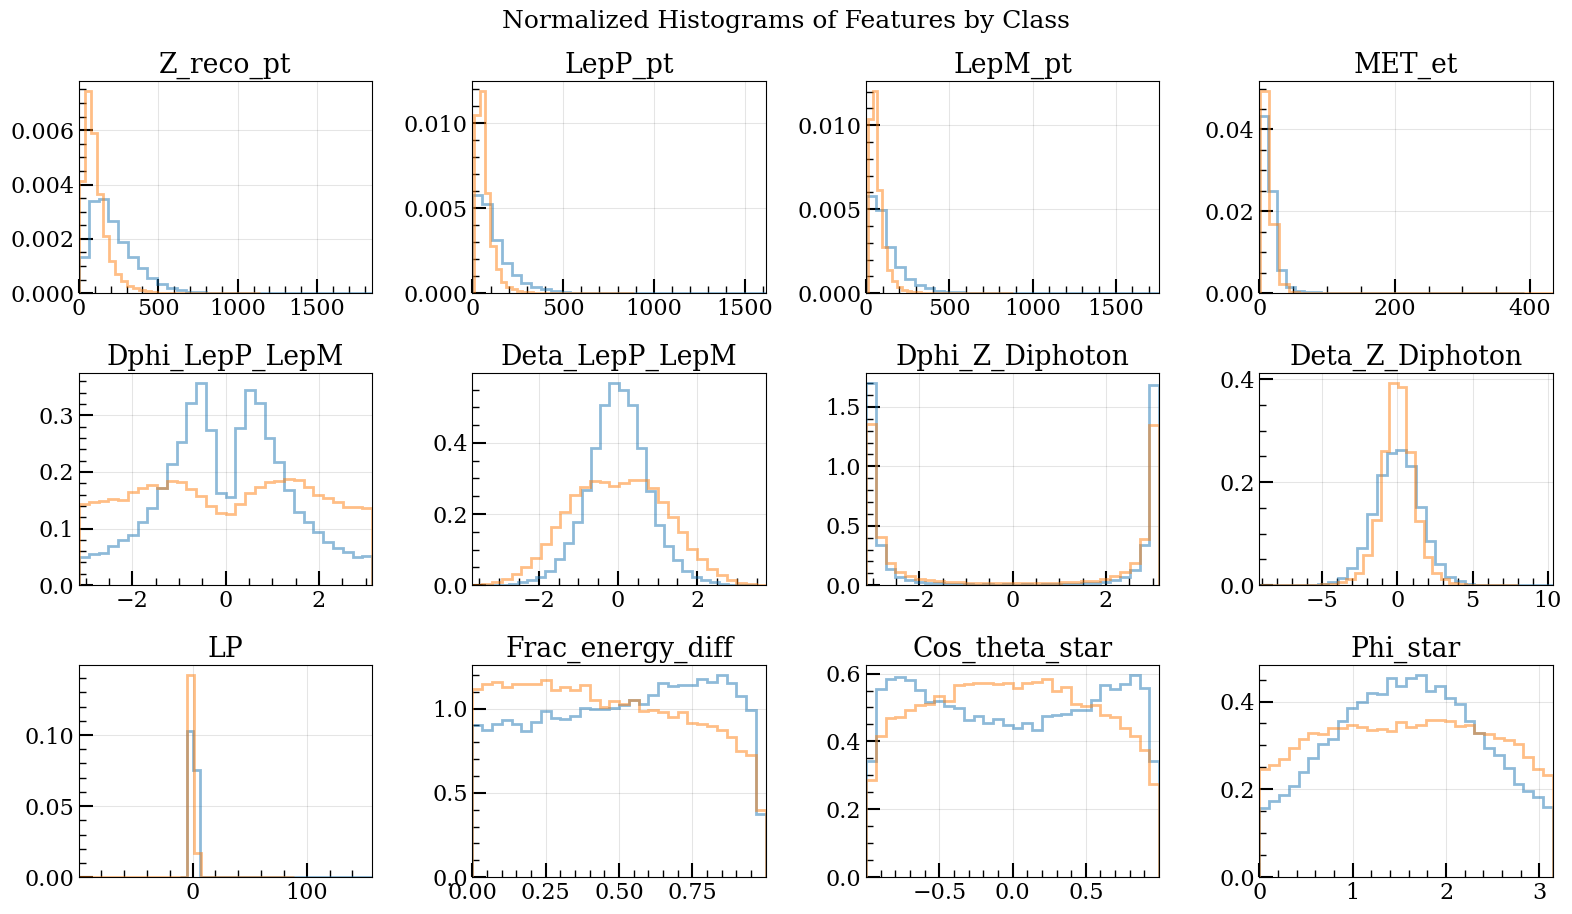

In [15]:
classes = [2,3]  
n_feat = len(all_feat)  # exclude 'label'
ncols = 4
nrows = int(np.ceil(n_feat / ncols))

plt.figure(figsize=(4 * ncols, 3 * nrows))

for idx, feat in enumerate(all_feat):  # exclude 'label'
    plt.subplot(nrows, ncols, idx + 1)
    for cls in classes:
        class_data = df_all[df_all['label'] == cls][feat]
        plt.hist(class_data,
                 bins=30,
                 alpha=0.5,
                 label=label_names.get(cls, str(cls)),
                 density=True,  # This normalizes histogram to unity area
                 histtype='step',
                 linewidth=2)
    plt.title(feat)
    #plt.legend('False')
    plt.tight_layout()

plt.suptitle('Normalized Histograms of Features by Class', y=1.02, fontsize=18)
plt.show()

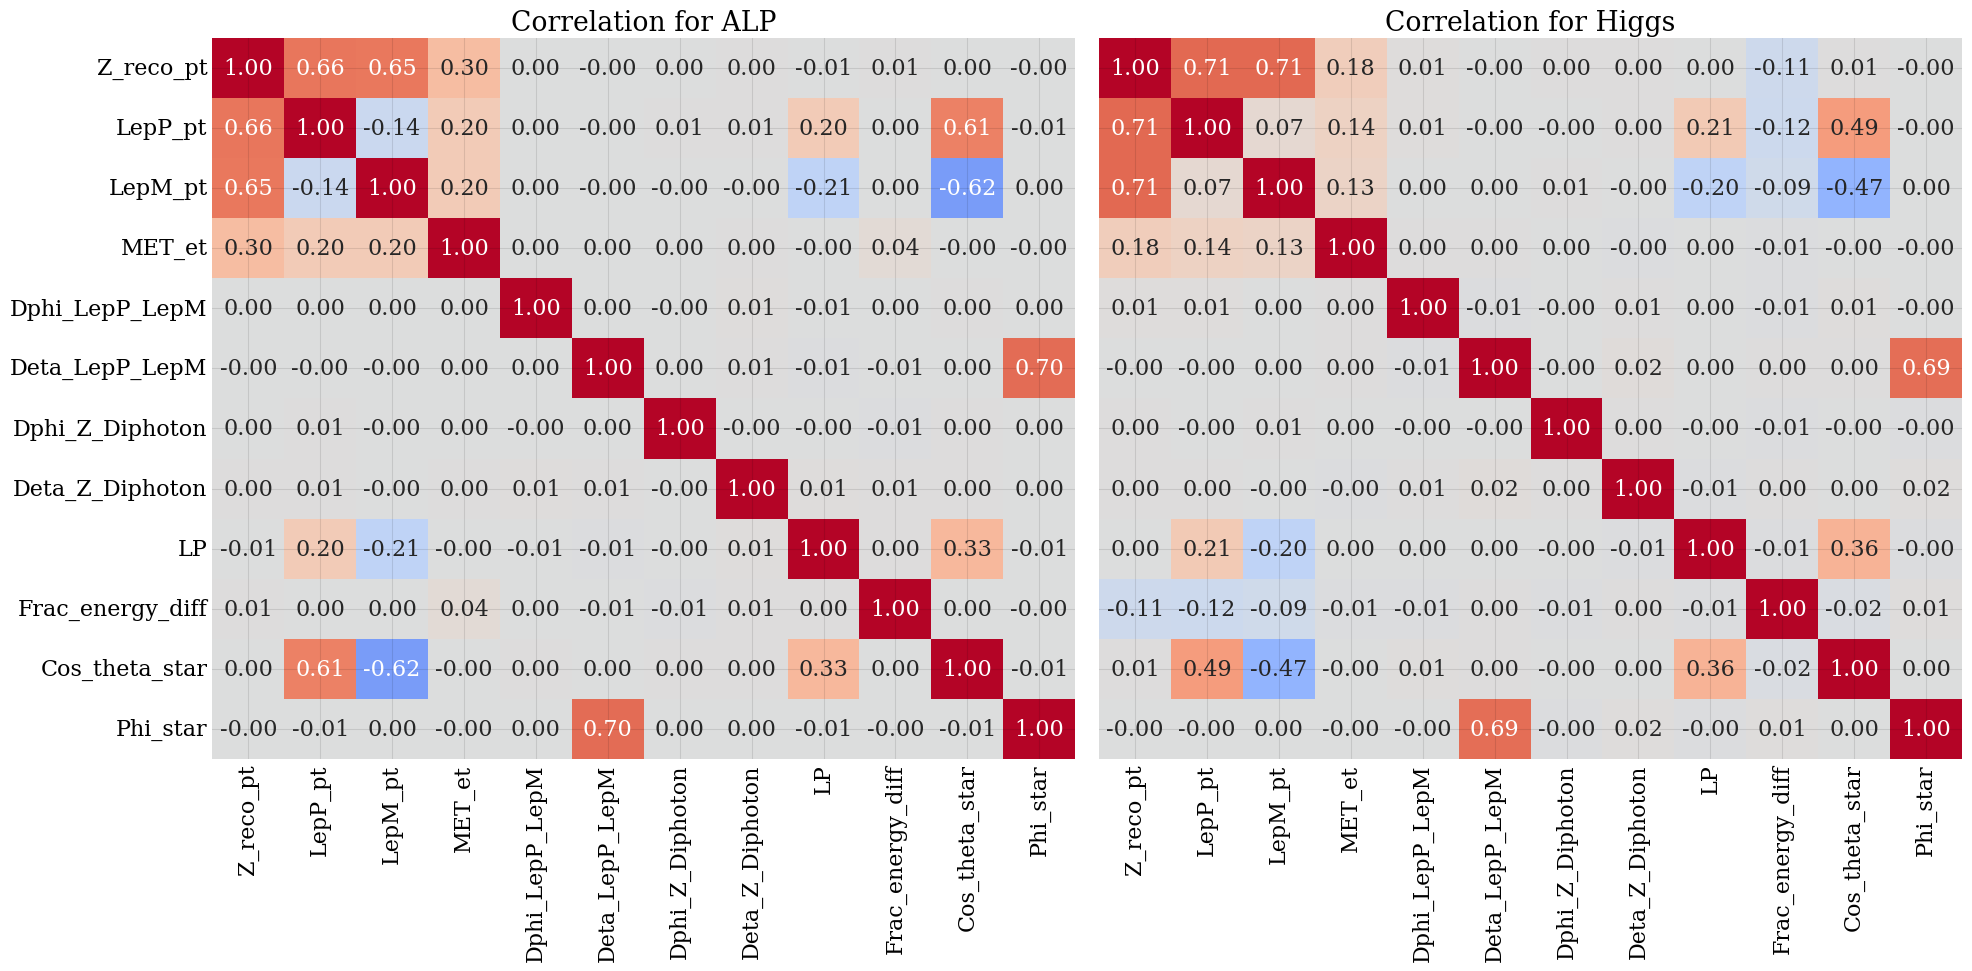

In [16]:
selected_labels = [2,3]  # 2 ALP, 3 Higgs

# Filter df_all for selected labels
df_selected = df_all[df_all['label'].isin(selected_labels)].copy()


df_2 = df_selected[df_selected['label'] == 2]
df_3 = df_selected[df_selected['label'] == 3]


cor_2 = df_2[all_feat].corr()
cor_3 = df_3[all_feat].corr()

#plt.rcParams["figure.figsize"] = (25, 6)

fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharex=True, sharey=True)

sns.heatmap(
    cor_2,
    annot=True,
    cmap="coolwarm",   # better for ± correlations
    center=0,
    fmt=".2f",
    cbar=False, 
    ax=axes[0]
)
axes[0].set_title("Correlation for ALP")

sns.heatmap(
    cor_3,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    cbar=False, 
    ax=axes[1]
)
axes[1].set_title("Correlation for Higgs")

for ax in axes:
    ax.tick_params(axis='both', which='both', length=0)
    ax.tick_params(axis='x', rotation=90)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig("ALP_ANALYSIS/correlation.png", dpi=300, bbox_inches="tight")
plt.show()


In [17]:

# Create binary labels: signal=1 (label 2), background=0 (labels 3)
df_selected['binary_label'] = np.where(df_selected['label'] == 2,1,0)

print(f"Original label distribution:")
print(df_selected['label'].value_counts().sort_index())
print(f"\nBinary label distribution:")
print(df_selected['binary_label'].value_counts())

# Prepare features and binary labels
all_feat = [f for f in all_feat if f not in ['LepM_pt', 'MET_et', 'LepP_pt']]# since it has high correlation
X = df_selected[all_feat]
y = df_selected['binary_label'].values  # Use binary labels!
weights = df_selected['weight'].values
# Verify binary labels
print(f"\nUnique labels in y: {np.unique(y)}")


Original label distribution:
label
2    480749
3    483556
Name: count, dtype: int64

Binary label distribution:
binary_label
0    483556
1    480749
Name: count, dtype: int64

Unique labels in y: [0 1]


In [18]:
weights

array([1, 1, 1, ..., 1, 1, 1])

In [19]:
X_train, X_test, y_train, y_test, weights_train, weights_test = train_test_split(X, y, weights, test_size=.2, random_state=0)
print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Class distribution: {np.bincount(y_train)}")


Training set size: (771444, 9)
Test set size: (192861, 9)
Class distribution: [387072 384372]


In [20]:

# Calculate effective sample sizes
n_signal_weighted = weights_train[y_train == 1].sum()
n_background_weighted = weights_train[y_train == 0].sum()

print(f"\nWeighted event counts in training:")
print(f"  Signal: {n_signal_weighted:.2f}")
print(f"  Background: {n_background_weighted:.2f}")
print(f"  Ratio (Bkg/Sig): {n_background_weighted/n_signal_weighted:.2f}")


Weighted event counts in training:
  Signal: 384372.00
  Background: 387072.00
  Ratio (Bkg/Sig): 1.01


In [21]:
# %time
# #warnings.filterwarnings(action='ignore', category=DeprecationWarning)


# model = xgb.sklearn.XGBClassifier(nthread=-1, 
#                                   seed=1, 
#                                   n_estimators=1000, 
#                                   #use_label_encoder=False, 
#                                   eval_metric='logloss')

# model.fit(X_train, y_train)

In [22]:
X_train

,Z_reco_pt,Dphi_LepP_LepM,Deta_LepP_LepM,Dphi_Z_Diphoton,Deta_Z_Diphoton,LP,Frac_energy_diff,Cos_theta_star,Phi_star
336367,320.749939,-0.552968,-0.079389,-3.130816,-1.787441,0.700407,0.394913,0.394913,1.451217
596917,81.487885,-1.963743,-0.056064,2.439712,2.026633,0.000686,0.498620,-0.498620,2.106888
796558,34.850323,-2.533127,-1.031241,-3.093448,-3.392156,-0.363681,0.090572,0.090572,0.695993
477283,646.774414,0.242839,-0.167619,-2.877945,-0.269035,0.663752,0.386693,0.386693,1.002586
796204,71.789238,1.752777,-0.689347,-1.902344,-0.488558,0.358394,0.227160,-0.227160,1.162990
...,...,...,...,...,...,...,...,...,...
152315,70.050491,1.318639,1.644925,2.069298,1.067474,0.593731,0.623701,0.623701,2.363387
963395,64.177994,1.820523,-0.850577,-3.007006,0.649503,0.287443,0.125947,0.125947,1.014938
117952,451.999695,0.073531,0.479350,3.138176,0.322962,0.811870,0.586527,0.586527,2.996107
435829,93.696480,-2.416603,-0.038208,-3.124111,-1.076709,1.140146,0.802797,0.802797,2.504416


In [23]:
print(xgb.__version__)


2.1.4


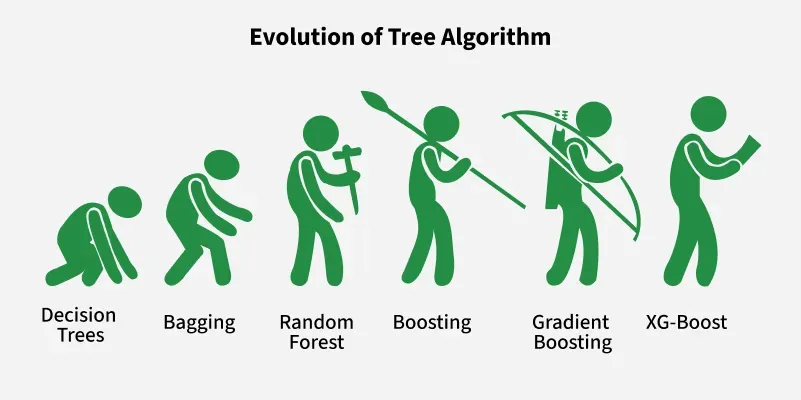

In [24]:
###################XGBoost parameters
print(xgb.__version__)
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc', # either with 'auc' or 'logloss'
    'max_depth': 6,
    'learning_rate': 0.02, # 0.03 previouysly 
    'n_estimators': 30000,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'early_stopping_rounds': 100, ## check if needed
    'n_jobs': -1,
    #'use_label_encoder': False
}




# params = {
#     'objective': 'binary:logistic',
#     'eval_metric': 'auc',
#     'max_depth': 4,
#     'learning_rate': 0.01,
#     'n_estimators': 10000,
#     'subsample': 0.8,
#     'colsample_bytree': 0.8,
#     'min_child_weight': 3,
#     'gamma': 0.1,
#     'reg_alpha': 0.0,
#     'reg_lambda': 1.0,
#     'random_state': 42,
#     'early_stopping': 100,
#     'n_jobs': -1
# }



model = xgb.XGBClassifier(**params)
    
model.fit(
        X_train, y_train,
        sample_weight=weights_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=1000
)

2.1.4
[0]	validation_0-auc:0.82087	validation_1-auc:0.82032
[1000]	validation_0-auc:0.87491	validation_1-auc:0.87115
[2000]	validation_0-auc:0.89566	validation_1-auc:0.88932
[3000]	validation_0-auc:0.91261	validation_1-auc:0.90424
[4000]	validation_0-auc:0.92667	validation_1-auc:0.91676
[5000]	validation_0-auc:0.93800	validation_1-auc:0.92699
[6000]	validation_0-auc:0.94738	validation_1-auc:0.93561
[7000]	validation_0-auc:0.95521	validation_1-auc:0.94291
[8000]	validation_0-auc:0.96176	validation_1-auc:0.94912
[9000]	validation_0-auc:0.96710	validation_1-auc:0.95433
[10000]	validation_0-auc:0.97159	validation_1-auc:0.95878
[11000]	validation_0-auc:0.97546	validation_1-auc:0.96270
[12000]	validation_0-auc:0.97871	validation_1-auc:0.96609
[13000]	validation_0-auc:0.98142	validation_1-auc:0.96898
[14000]	validation_0-auc:0.98375	validation_1-auc:0.97148
[15000]	validation_0-auc:0.98574	validation_1-auc:0.97371
[16000]	validation_0-auc:0.98748	validation_1-auc:0.97568
[17000]	validation_0-

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=100,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.02, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=30000, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

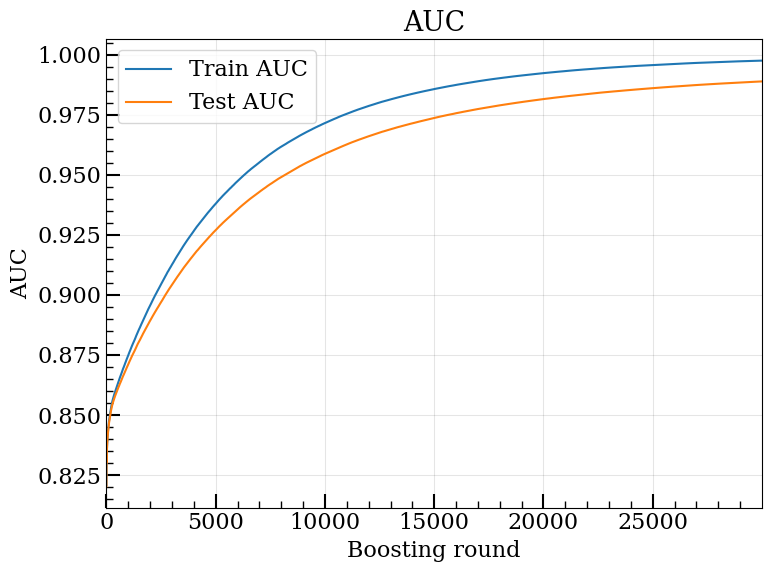

In [25]:
results = model.evals_result()
epochs = range(len(results['validation_0']['auc']))
#epochs = range(len(results['validation_0']['logloss']))


fig, axes = plt.subplots(1, 1, figsize=(8, 6))

axes.plot(epochs, results['validation_0']['auc'], label='Train AUC')
axes.plot(epochs, results['validation_1']['auc'], label='Test AUC')
axes.set_title('AUC')
axes.set_xlabel('Boosting round')
axes.set_ylabel('AUC')
axes.legend()

# axes[1].plot(epochs, results['validation_0']['logloss'], label='Train LogLoss')
# axes[1].plot(epochs, results['validation_1']['logloss'], label='Test LogLoss')
# axes[1].set_title('LogLoss')
# axes[1].set_xlabel('Boosting round')
# axes[1].set_ylabel('LogLoss')
# axes[1].legend()

plt.tight_layout()
plt.savefig('ALP_ANALYSIS/auc_optimazation_rounds.png', dpi=300, bbox_inches='tight')
plt.show()


Train AUC: 0.9976
Test AUC: 0.9889

Classification Report (Test Set):
              precision    recall  f1-score   support

  Background       0.96      0.96      0.96     96484
      Signal       0.96      0.95      0.96     96377

    accuracy                           0.96    192861
   macro avg       0.96      0.96      0.96    192861
weighted avg       0.96      0.96      0.96    192861



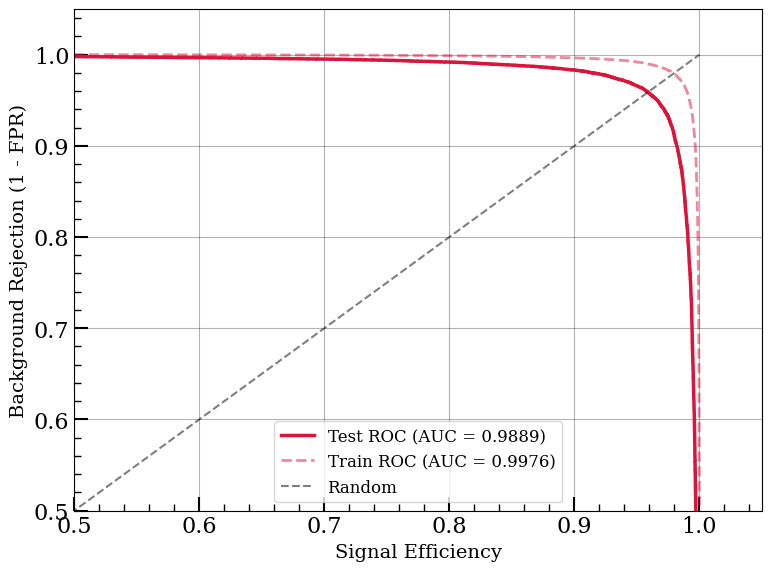

In [26]:
y_train_pred_proba = model.predict_proba(X_train)[:, 1]
y_test_pred_proba = model.predict_proba(X_test)[:, 1]
y_test_pred = model.predict(X_test)

# ROC and AUC
from sklearn.metrics import roc_curve, auc, classification_report

fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_proba, sample_weight=weights_train)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_proba, sample_weight=weights_test)

auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)

print(f"\n{'='*50}")
print(f"Train AUC: {auc_train:.4f}")
print(f"Test AUC: {auc_test:.4f}")
print(f"{'='*50}")

# Classification report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, 
                           target_names=['Background', 'Signal']))

bkg_rejection_train = 1 - fpr_train



plt.figure(figsize=(8, 6))
plt.plot(tpr_test, 1 - fpr_test, color='crimson', lw=2.5,
          label=f'Test ROC (AUC = {auc_test:.4f})')
plt.plot(tpr_train, bkg_rejection_train, color='crimson', lw=2, linestyle='--', alpha=0.5,
         label=f'Train ROC (AUC = {auc_train:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random')

plt.xlabel('Signal Efficiency', fontsize=14)
plt.ylabel('Background Rejection (1 - FPR)', fontsize=14)
#plt.title(f'ROC Curve: Signal A_0.5 vs Backgrounds L={int_luminosity} fb⁻¹', fontsize=14, pad=15)
plt.legend(loc='lower center', fontsize=12)
plt.grid(alpha=0.3)
plt.xlim([0.5, 1.05])
plt.ylim([0.5, 1.05])
#plt.xscale('log')
#plt.yscale('log')

plt.tight_layout()
plt.savefig('ALP_ANALYSIS/roc_curve_ALP_Z_v_Higgs_Z_125.png', dpi=300, bbox_inches='tight')
plt.show()

KS Test: KstestResult(statistic=0.01706410316238116, pvalue=1.8664625792832414e-39, statistic_location=0.8161605, statistic_sign=-1)


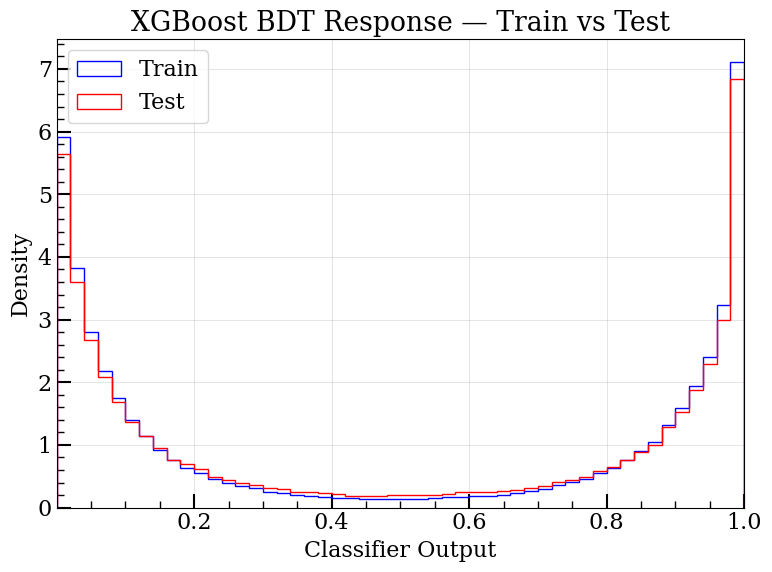

In [27]:
from scipy.stats import ks_2samp
# --- KS Test ---
ks_value = ks_2samp(y_train_pred_proba, y_test_pred_proba)
print("KS Test:", ks_value)
plt.figure(figsize=(8, 6))
plt.hist(y_train_pred_proba, bins=50, density=True, histtype='step', label="Train", color='blue')
plt.hist(y_test_pred_proba,  bins=50, density=True, histtype='step', label="Test",  color='red')

plt.title("XGBoost BDT Response — Train vs Test")
plt.xlabel("Classifier Output")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.savefig('ALP_ANALYSIS/XGBOOST_response.png', dpi=300, bbox_inches='tight')
plt.show()


plt.show()




Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     96484
           1       0.96      0.95      0.96     96377

    accuracy                           0.96    192861
   macro avg       0.96      0.96      0.96    192861
weighted avg       0.96      0.96      0.96    192861



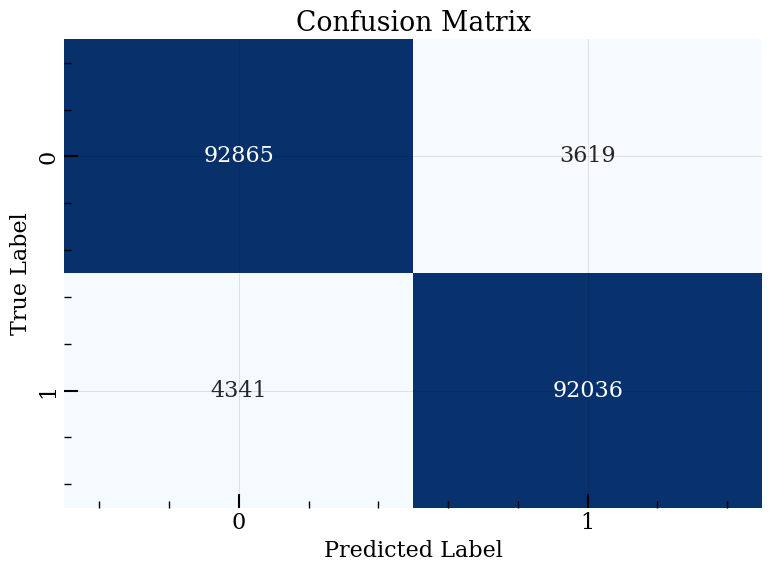

In [28]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))


plt.tight_layout()
plt.savefig('ALP_ANALYSIS/confusion_mat.png', dpi=300, bbox_inches='tight')
plt.show()



In [29]:
# xgb.plot_importance(model, importance_type='gain', max_num_features=20)
# plt.title("XGBoost Feature Importance (Gain)")
# plt.tight_layout()
# plt.show()

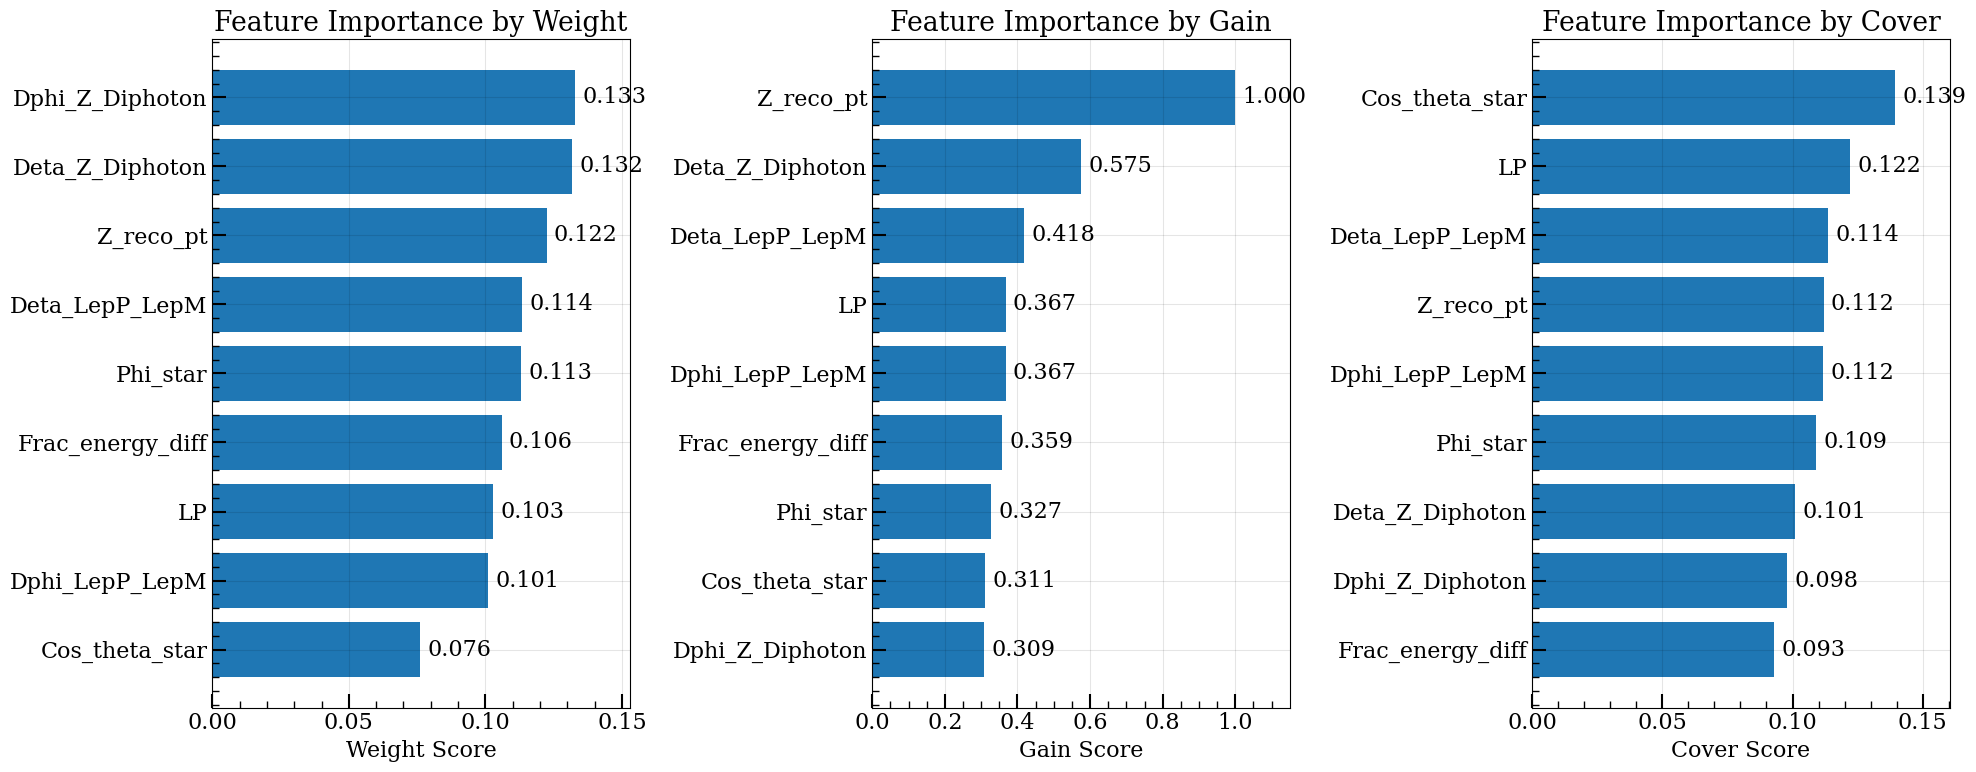

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

types = ['weight', 'gain', 'cover']
x_labels = ['Weight Score', 'Gain Score', 'Cover Score']
titles = ['Feature Importance by Weight', 'Feature Importance by Gain', 'Feature Importance by Cover']

for i, imp_type in enumerate(types):
    importances = model.get_booster().get_score(importance_type=imp_type)
    items = sorted(importances.items(), key=lambda x: x[1], reverse=True)[:20]

    features = [k for k, v in items]
    values = np.array([v for k, v in items], dtype=float)

    if imp_type == 'weight':
        values_plot = values / values.sum()
    elif imp_type == 'gain':
        values_plot = values / values.max()
    else:
        values_plot = values / values.sum()

    axes[i].barh(range(len(features)), values_plot)
    axes[i].set_yticks(range(len(features)))
    axes[i].set_yticklabels(features)
    axes[i].set_xlabel(x_labels[i])
    axes[i].set_title(titles[i])
    axes[i].invert_yaxis()

    xmax = values_plot.max()
    axes[i].set_xlim(0, xmax * 1.15)   # 15% extra space on right

    for j, v in enumerate(values_plot):
        axes[i].text(v + xmax * 0.02, j, f'{v:.3f}', va='center')

plt.tight_layout()
plt.savefig('ALP_ANALYSIS/variable_imp.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
model.save_model("xgb_model.json")

100%|===================| 499/500 [10:21<00:01]        

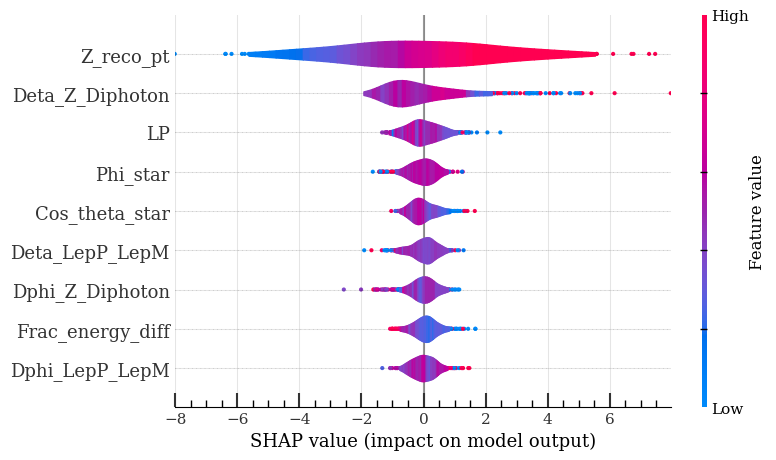

In [32]:


explainer = shap.Explainer(model, X_train.sample(1000, random_state=42))   # pass background data
shap_values = explainer(X_test[:500])

plt.clf()  # Clear any existing figure
shap.plots.violin(
    shap_values,
    max_display=12
)

plt.xlabel("SHAP value (impact on model output)")
plt.tight_layout()
plt.savefig("ALP_ANALYSIS/shap_violin.png", dpi=300)
plt.close() 

## Boosted Analysis

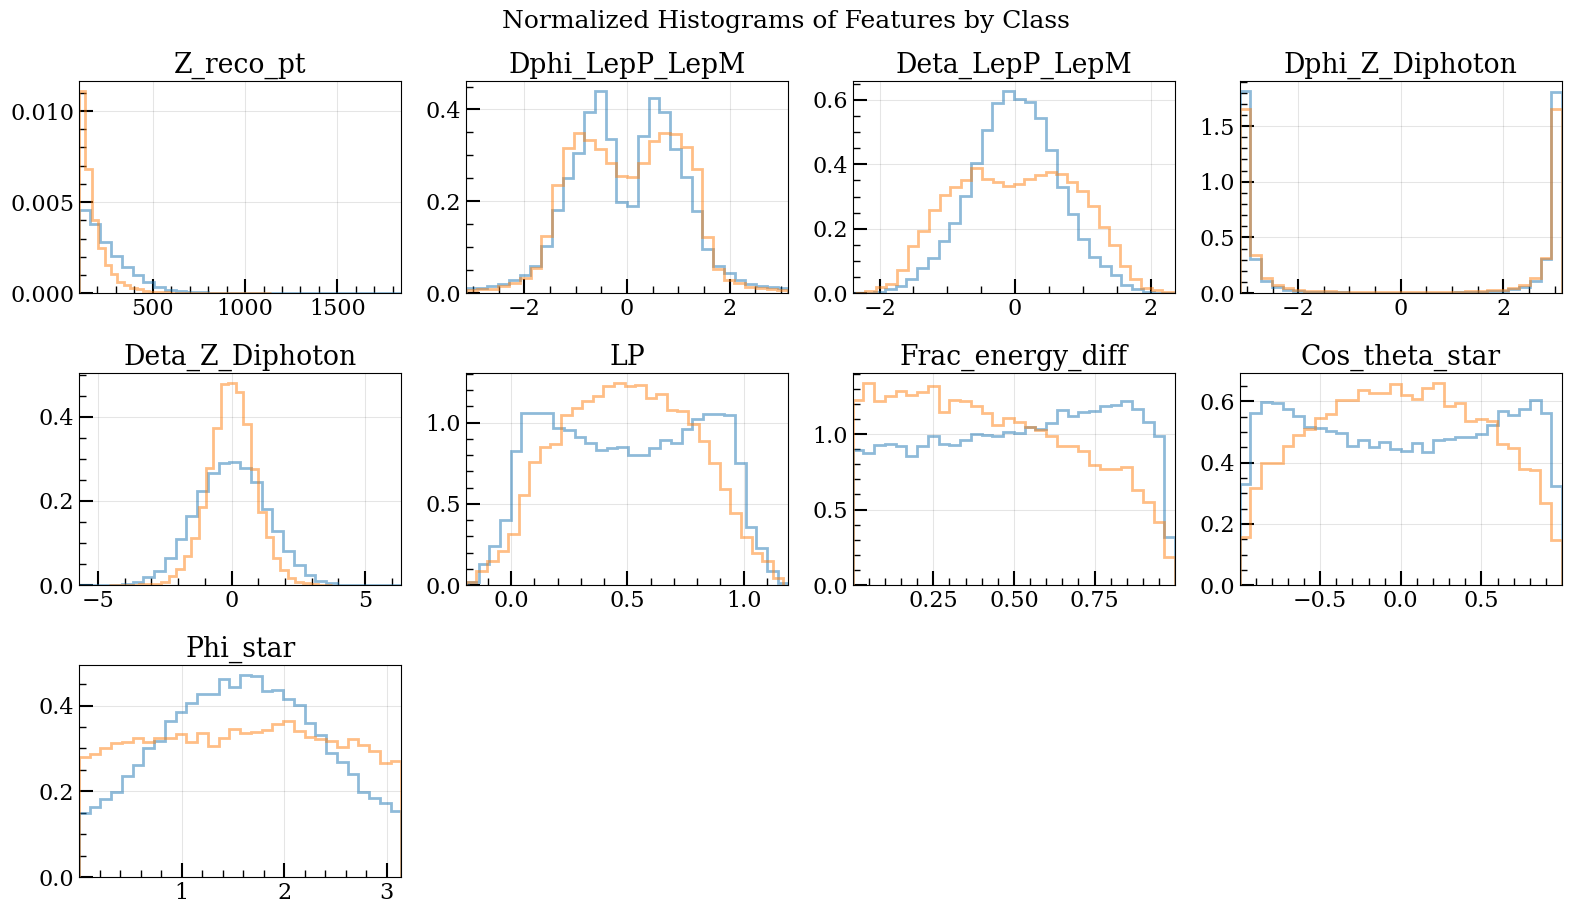

In [33]:
df_all_boost = df_all[df_all["Z_reco_pt"] > 100]

classes = [2,3]  
n_feat = len(all_feat)  # exclude 'label'
ncols = 4
nrows = int(np.ceil(n_feat / ncols))

plt.figure(figsize=(4 * ncols, 3 * nrows))

for idx, feat in enumerate(all_feat):  # exclude 'label'
    plt.subplot(nrows, ncols, idx + 1)
    for cls in classes:
        class_data = df_all_boost[df_all_boost['label'] == cls][feat]
        plt.hist(class_data,
                 bins=30,
                 alpha=0.5,
                 label=label_names.get(cls, str(cls)),
                 density=True,  # This normalizes histogram to unity area
                 histtype='step',
                 linewidth=2)
    plt.title(feat)
    #plt.legend('False')
    plt.tight_layout()

plt.suptitle('Normalized Histograms of Features by Class', y=1.02, fontsize=18)
plt.show()

In [34]:

# Filter df_all for selected labels
df_selected_boost = df_all_boost[df_all_boost['label'].isin(selected_labels)].copy()

# Create binary labels: signal=1 (label 2), background=0 (labels 3)
df_selected_boost['binary_label'] = np.where(df_selected_boost['label'] == 2,1,0)

print(f"Original label distribution:")
print(df_selected_boost['label'].value_counts().sort_index())
print(f"\nBinary label distribution:")
print(df_selected_boost['binary_label'].value_counts())

# Prepare features and binary labels
X_boost = df_selected_boost[all_feat]
y_boost = df_selected_boost['binary_label'].values  # Use binary labels!
weights_boost = df_selected_boost['weight'].values
# Verify binary labels
print(f"\nUnique labels in y: {np.unique(y_boost)}")


X_train_boost, X_test_boost, y_train_boost, y_test_boost, weights_train_boost, weights_test_boost = train_test_split(X_boost, y_boost, weights_boost, test_size=.2, random_state=0)
print(f"Training set size: {X_train_boost.shape}")
print(f"Test set size: {X_test_boost.shape}")
print(f"Class distribution: {np.bincount(y_train_boost)}")



Original label distribution:
label
2    382297
3    198138
Name: count, dtype: int64

Binary label distribution:
binary_label
1    382297
0    198138
Name: count, dtype: int64

Unique labels in y: [0 1]
Training set size: (464348, 9)
Test set size: (116087, 9)
Class distribution: [158377 305971]


In [35]:
model_boost = xgb.XGBClassifier(**params)

model_boost.fit(
        X_train_boost, y_train_boost,
        sample_weight=weights_train_boost,
        eval_set=[(X_train_boost, y_train_boost), (X_test_boost, y_test_boost)],
        verbose=100
)

[0]	validation_0-auc:0.77716	validation_1-auc:0.77566
[100]	validation_0-auc:0.81328	validation_1-auc:0.81141
[200]	validation_0-auc:0.82181	validation_1-auc:0.81938
[300]	validation_0-auc:0.82854	validation_1-auc:0.82557
[400]	validation_0-auc:0.83388	validation_1-auc:0.83037
[500]	validation_0-auc:0.83940	validation_1-auc:0.83525
[600]	validation_0-auc:0.84444	validation_1-auc:0.83963
[700]	validation_0-auc:0.84953	validation_1-auc:0.84411
[800]	validation_0-auc:0.85442	validation_1-auc:0.84837
[900]	validation_0-auc:0.85897	validation_1-auc:0.85235
[1000]	validation_0-auc:0.86361	validation_1-auc:0.85642
[1100]	validation_0-auc:0.86803	validation_1-auc:0.86023
[1200]	validation_0-auc:0.87227	validation_1-auc:0.86390
[1300]	validation_0-auc:0.87637	validation_1-auc:0.86745
[1400]	validation_0-auc:0.88037	validation_1-auc:0.87092
[1500]	validation_0-auc:0.88429	validation_1-auc:0.87440
[1600]	validation_0-auc:0.88787	validation_1-auc:0.87753
[1700]	validation_0-auc:0.89144	validation_

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=100,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.02, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=30000, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

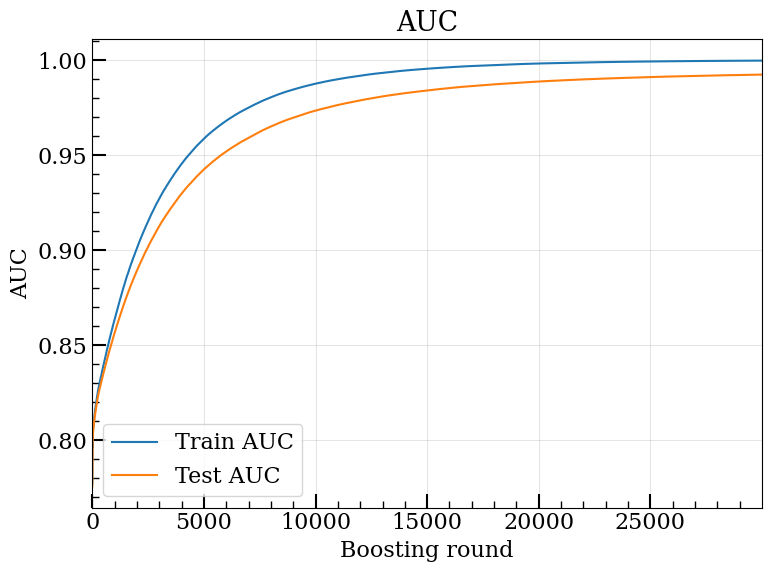

In [36]:
results = model_boost.evals_result()
epochs = range(len(results['validation_0']['auc']))
#epochs = range(len(results['validation_0']['logloss']))


fig, axes = plt.subplots(1, 1, figsize=(8, 6))

axes.plot(epochs, results['validation_0']['auc'], label='Train AUC')
axes.plot(epochs, results['validation_1']['auc'], label='Test AUC')
axes.set_title('AUC')
axes.set_xlabel('Boosting round')
axes.set_ylabel('AUC')
axes.legend()

# axes[1].plot(epochs, results['validation_0']['logloss'], label='Train LogLoss')
# axes[1].plot(epochs, results['validation_1']['logloss'], label='Test LogLoss')
# axes[1].set_title('LogLoss')
# axes[1].set_xlabel('Boosting round')
# axes[1].set_ylabel('LogLoss')
# axes[1].legend()

plt.tight_layout()
plt.show()


Train AUC: 0.9997
Test AUC: 0.9924

Classification Report (Test Set):
              precision    recall  f1-score   support

  Background       0.97      0.95      0.96     39761
      Signal       0.98      0.98      0.98     76326

    accuracy                           0.97    116087
   macro avg       0.97      0.97      0.97    116087
weighted avg       0.97      0.97      0.97    116087



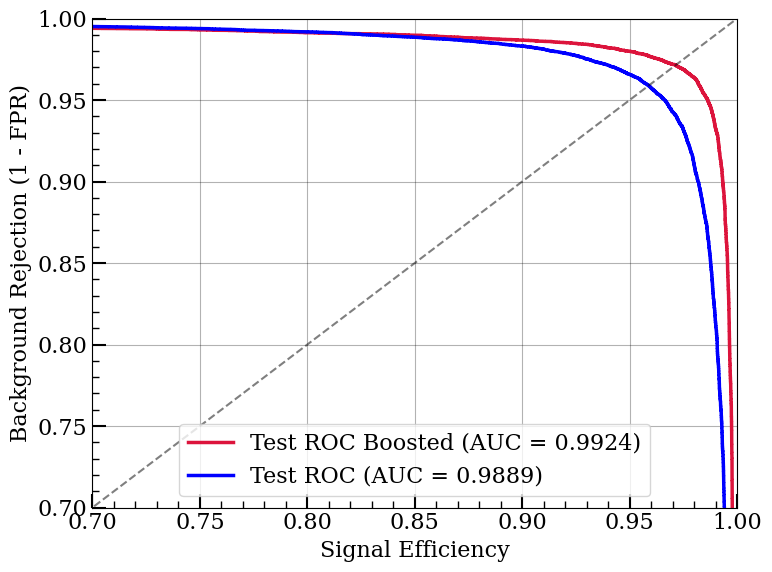

In [37]:
y_train_pred_proba_boost = model_boost.predict_proba(X_train_boost)[:, 1]
y_test_pred_proba_boost = model_boost.predict_proba(X_test_boost)[:, 1]
y_test_pred_boost = model_boost.predict(X_test_boost)

fpr_train_boost, tpr_train_boost, _ = roc_curve(y_train_boost, y_train_pred_proba_boost, sample_weight=weights_train_boost)
fpr_test_boost, tpr_test_boost, _ = roc_curve(y_test_boost, y_test_pred_proba_boost, sample_weight=weights_test_boost)

auc_train_boost = auc(fpr_train_boost, tpr_train_boost)
auc_test_boost = auc(fpr_test_boost, tpr_test_boost)

print(f"\n{'='*50}")
print(f"Train AUC: {auc_train_boost:.4f}")
print(f"Test AUC: {auc_test_boost:.4f}")
print(f"{'='*50}")

# Classification report
print("\nClassification Report (Test Set):")
print(classification_report(y_test_boost, y_test_pred_boost, 
                           target_names=['Background', 'Signal']))

bkg_rejection_train_boost = 1 - fpr_train_boost



plt.figure(figsize=(8, 6))
plt.plot(tpr_test_boost, 1 - fpr_test_boost, color='crimson', lw=2.5, label=f'Test ROC Boosted (AUC = {auc_test_boost:.4f})')
#plt.plot(tpr_train_boost, bkg_rejection_train_boost, color='crimson', lw=2, linestyle='--', alpha=0.5, label=f'Train ROC (AUC = {auc_train_boost:.4f})')

plt.plot(tpr_test, 1 - fpr_test, color='blue', lw=2.5, label=f'Test ROC (AUC = {auc_test:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5)

plt.xlabel('Signal Efficiency')
plt.ylabel('Background Rejection (1 - FPR)')
#plt.title(f'ROC Curve: Signal A_0.5 vs Backgrounds L={int_luminosity} fb⁻¹', fontsize=14, pad=15)
plt.legend(loc='lower center')
plt.grid(alpha=0.3)
plt.xlim([0.7, 1.])
plt.ylim([0.7, 1.])
#plt.xscale('log')
#plt.yscale('log')

plt.tight_layout()
plt.savefig('ALP_ANALYSIS/roc_curve_ALP_Z_v_Higgs_Z_125_boost.png', dpi=300, bbox_inches='tight')
plt.show()

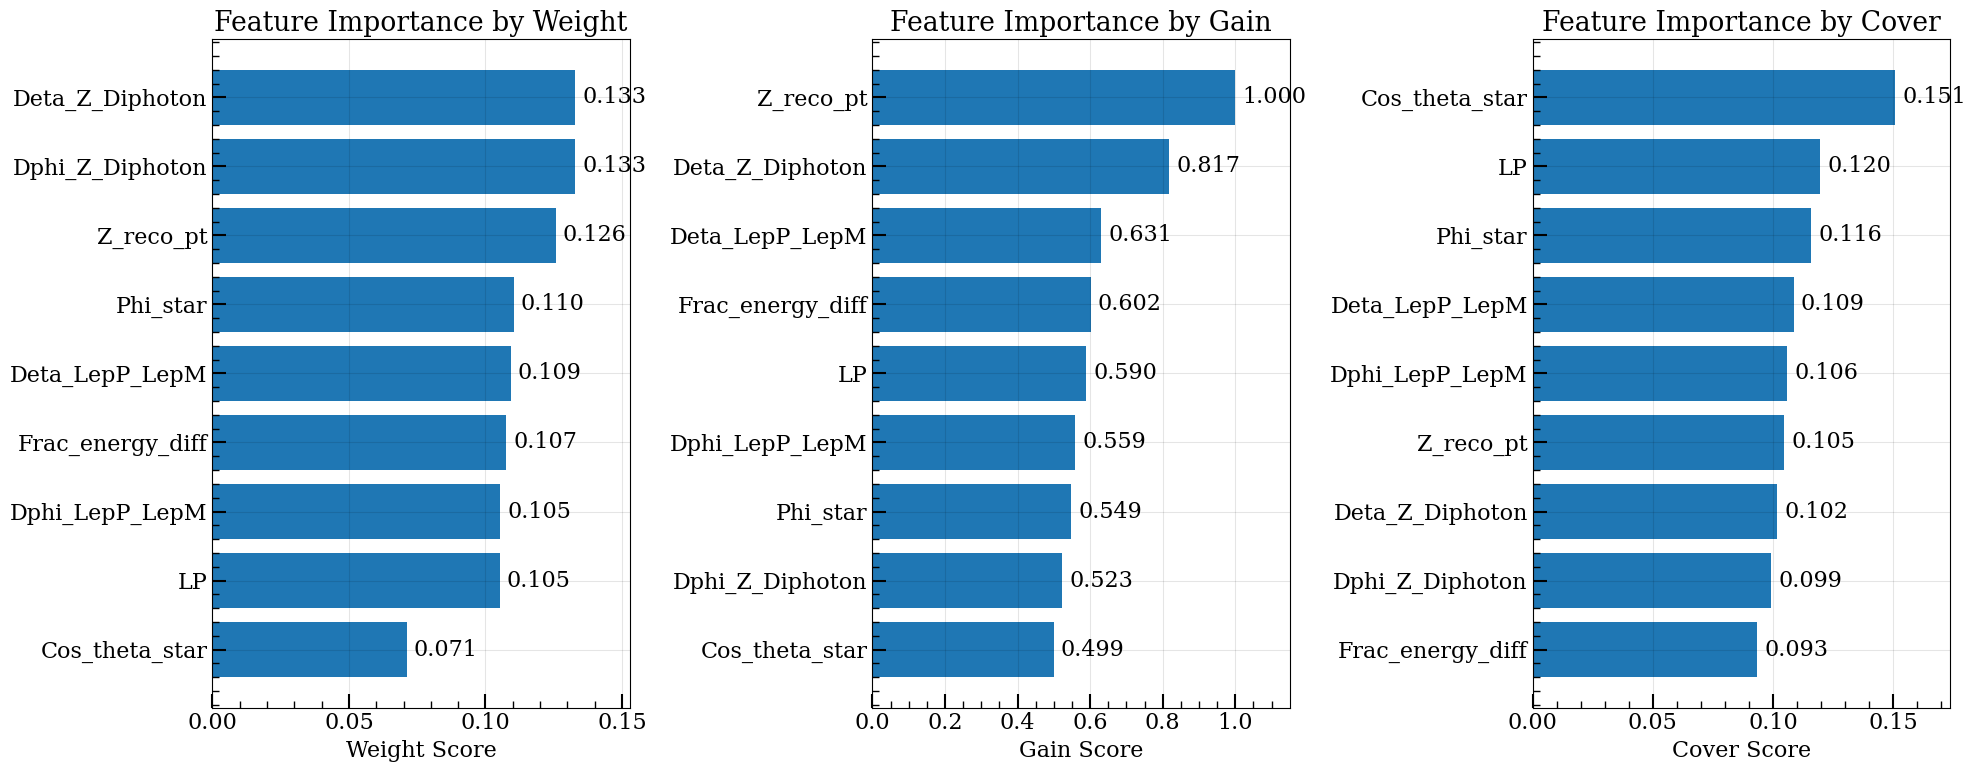

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

types = ['weight', 'gain', 'cover']
x_labels = ['Weight Score', 'Gain Score', 'Cover Score']
titles = ['Feature Importance by Weight', 'Feature Importance by Gain', 'Feature Importance by Cover']

for i, imp_type in enumerate(types):
    importances = model_boost.get_booster().get_score(importance_type=imp_type)
    items = sorted(importances.items(), key=lambda x: x[1], reverse=True)[:20]

    features = [k for k, v in items]
    values = np.array([v for k, v in items], dtype=float)

    if imp_type == 'weight':
        values_plot = values / values.sum()
    elif imp_type == 'gain':
        values_plot = values / values.max()
    else:
        values_plot = values / values.sum()

    axes[i].barh(range(len(features)), values_plot)
    axes[i].set_yticks(range(len(features)))
    axes[i].set_yticklabels(features)
    axes[i].set_xlabel(x_labels[i])
    axes[i].set_title(titles[i])
    axes[i].invert_yaxis()

    xmax = values_plot.max()
    axes[i].set_xlim(0, xmax * 1.15)   # 15% extra space on right

    for j, v in enumerate(values_plot):
        axes[i].text(v + xmax * 0.02, j, f'{v:.3f}', va='center')

plt.tight_layout()
plt.savefig('ALP_ANALYSIS/variable_imp_boost.png', dpi=300, bbox_inches='tight')
plt.show()

100%|===================| 499/500 [10:50<00:01]        

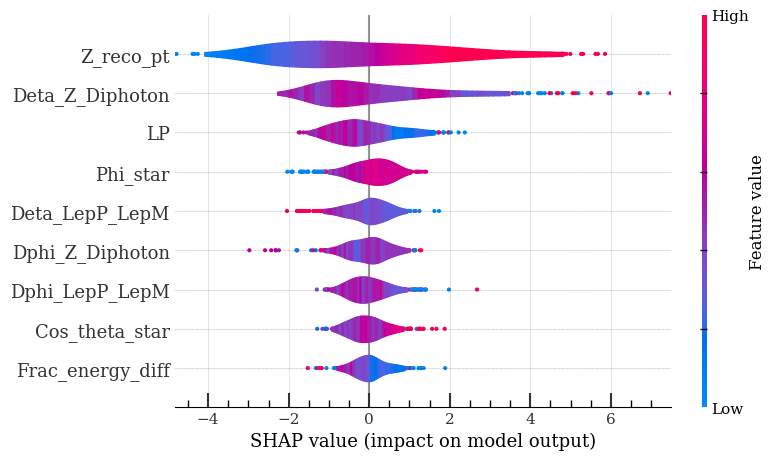

In [39]:


explainer = shap.Explainer(model_boost, X_train_boost.sample(1000, random_state=42))   # pass background data
shap_values = explainer(X_test_boost[:500])

plt.clf()  # Clear any existing figure
shap.plots.violin(
    shap_values,
    max_display=12
)
plt.xlabel("SHAP value (impact on model output)")
plt.tight_layout()
plt.savefig("ALP_ANALYSIS/shap_violin_boost.png", dpi=300, bbox_inches='tight')
plt.close()  # Close to prevent display


## BDT

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier




base_estimator = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features=0.8,         # Use 80% of features per split (reduces correlation)
    criterion='gini',         # Split quality measure (default)
    random_state=42
)

# AdaBoost classifier (BDT)
bdt = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=200,          # Number of boosting stages
    learning_rate=0.05,         # Learning rate (shrinks contribution of each tree)
    algorithm='SAMME.R',       # Use SAMME.R for probability estimates
    random_state=42
)


# ---------------------------------------------------------
# Train with sample weights
# ---------------------------------------------------------
bdt.fit(X_train, y_train, sample_weight=weights_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=5,
                                                    max_features=0.8,
                                                    min_samples_leaf=5,
                                                    min_samples_split=10,
                                                    random_state=42),
                   learning_rate=0.05, n_estimators=200, random_state=42)

In [ ]:
# ---------------------------------------------------------
# Predict probabilities for ROC
# ---------------------------------------------------------
y_prob = bdt.predict_proba(X_test)[:, 1]   # probability of class=1 (signal)
# Confusion Matrix
y_pred = bdt.predict(X_test)


cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[75256 21228]
 [22642 73735]]


AUC = 0.8564
At 60% signal efficiency:
  FPR = 0.2569
  Background rejection = 3.89


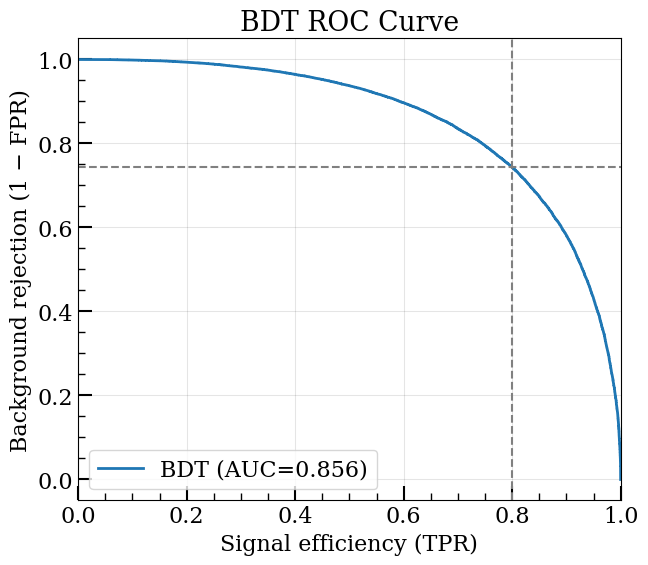

In [ ]:
# ---------------------------------------------------------
# ROC curve
# ---------------------------------------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_prob, sample_weight=weights_test)
roc_auc = auc(fpr, tpr)
print(f"AUC = {roc_auc:.4f}")

# ---------------------------------------------------------
# Compute background rejection at 60% signal efficiency
# ---------------------------------------------------------
target_tpr = 0.80
fpr_at_target = np.interp(target_tpr, tpr, fpr)
bkg_rejection = 1 / fpr_at_target

print(f"At 60% signal efficiency:")
print(f"  FPR = {fpr_at_target:.4f}")
print(f"  Background rejection = {bkg_rejection:.2f}")

# ---------------------------------------------------------
# Plot ROC (1 - FPR vs TPR)
# ---------------------------------------------------------
plt.figure(figsize=(7, 6))
plt.plot(tpr, 1 - fpr, label=f"BDT (AUC={roc_auc:.3f})", lw=2)

plt.axvline(target_tpr, color='gray', ls='--')
plt.axhline(1 - fpr_at_target, color='gray', ls='--')

plt.xlabel("Signal efficiency (TPR)")
plt.ylabel("Background rejection (1 − FPR)")
plt.title("BDT ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


Plots saved as 'BDT_analysis.png'


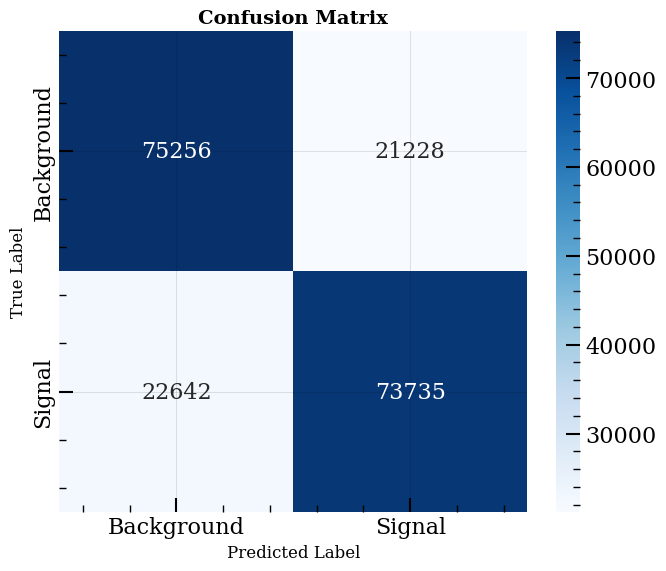

In [ ]:
plt.figure(figsize=(7, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Background', 'Signal'],
            yticklabels=['Background', 'Signal'])
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('BDT_analysis.png', dpi=300, bbox_inches='tight')
print("\nPlots saved as 'BDT_analysis.png'")
plt.show()


Top 10 Normalized Feature Importances:
LP: 0.2031
Dphi_LepP_LepM: 0.1651
Deta_LepP_LepM: 0.1536
Deta_Z_Diphoton: 0.1494
Phi_star: 0.1131
Frac_energy_diff: 0.1007
Dphi_Z_Diphoton: 0.0737
Cos_theta_star: 0.0413


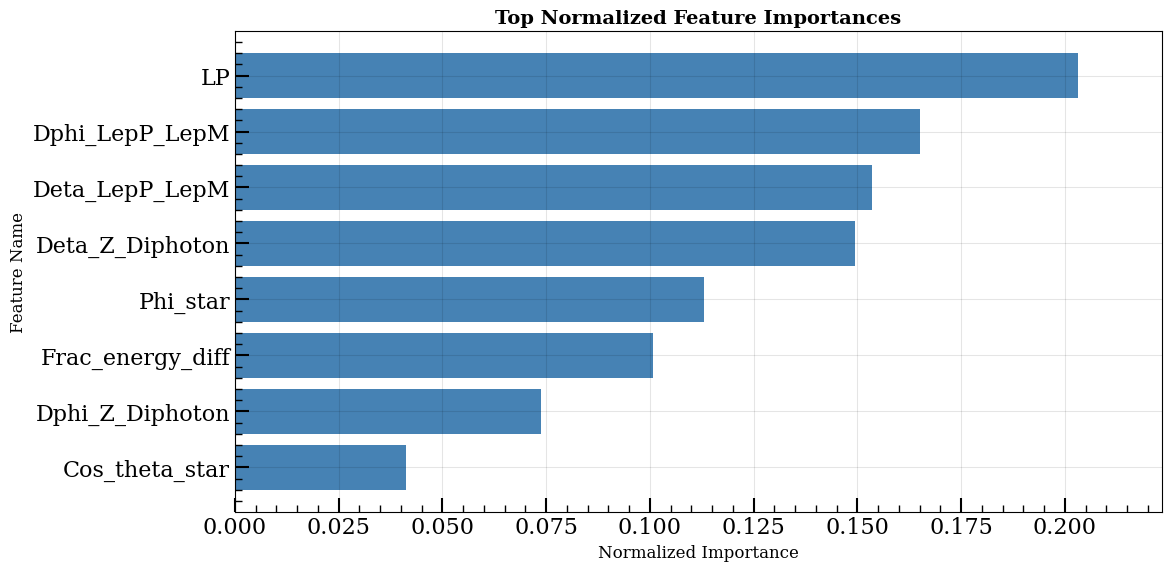

In [ ]:
if hasattr(bdt, 'feature_importances_'):
    feature_importances = bdt.feature_importances_
    # Normalize importances to sum to 1
    feature_importances = feature_importances / feature_importances.sum()
    
    feature_indices = np.argsort(feature_importances)[::-1]
    
    print("\nTop 10 Normalized Feature Importances:")
    for i in range(min(10, len(feature_importances))):
        feat_idx = feature_indices[i]
        print(f"{all_feat[feat_idx]}: {feature_importances[feat_idx]:.4f}")
    
    # Plot normalized feature importances
    plt.figure(figsize=(12, 6))  # Adjusted width for readability
    top_n = min(20, len(feature_importances))  # Show top 20 features
    indices = feature_indices[:top_n]
    
    plt.barh(range(top_n), feature_importances[indices], color='steelblue')
    plt.yticks(range(top_n), [all_feat[i] for i in indices])
    plt.xlabel('Normalized Importance', fontsize=12)
    plt.ylabel('Feature Name', fontsize=12)
    plt.title('Top Normalized Feature Importances', fontsize=14, fontweight='bold')
    plt.xlim(0, feature_importances[indices].max() * 1.1)  # 10% margin above max

    plt.gca().invert_yaxis()  # Highest importance at top
    plt.tight_layout()
    plt.savefig('feature_importances.png', dpi=300, bbox_inches='tight')
    plt.show()


In [ ]:
def plot_bdt_response_advanced(y_train, y_train_pred_proba, y_test, y_test_pred_proba, 
                               bins=50, **kwargs):
    """
    Advanced BDT response plot with error bars on training points
    """
    
    weights_train = kwargs.get('weights_train', None)
    weights_test = kwargs.get('weights_test', None)
    figsize = kwargs.get('figsize', (12, 8))
    title = kwargs.get('title', 'BDT Response')
    log_scale = kwargs.get('log_scale', False)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Separate signal and background
    test_sig_mask = y_test == 1
    test_bkg_mask = y_test == 0
    train_sig_mask = y_train == 1
    train_bkg_mask = y_train == 0
    
    # Get weights
    w_test_sig = weights_test[test_sig_mask] if weights_test is not None else None
    w_test_bkg = weights_test[test_bkg_mask] if weights_test is not None else None
    w_train_sig = weights_train[train_sig_mask] if weights_train is not None else None
    w_train_bkg = weights_train[train_bkg_mask] if weights_train is not None else None
    
    # Define bins
    bin_edges = np.linspace(0, 1, bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]
    
    # ========================================================================
    # TEST: Histograms with edge lines
    # ========================================================================
    
    # Test Signal
    hist_test_sig, _ = np.histogram(y_test_pred_proba[test_sig_mask], 
                                      bins=bin_edges, weights=w_test_sig, density=True)
    ax.bar(bin_centers, hist_test_sig, width=bin_width, 
           alpha=0.3, color='red', edgecolor='darkred', linewidth=1.5,
           label='Test Signal')
    
    # Test Background
    hist_test_bkg, _ = np.histogram(y_test_pred_proba[test_bkg_mask], 
                                      bins=bin_edges, weights=w_test_bkg, density=True)
    ax.bar(bin_centers, hist_test_bkg, width=bin_width, 
           alpha=0.3, color='blue', edgecolor='darkblue', linewidth=1.5,
           label='Test Background')
    
    # ========================================================================
    # TRAIN: Points with error bars
    # ========================================================================
    
    # Train Signal
    hist_train_sig, _ = np.histogram(y_train_pred_proba[train_sig_mask], 
                                       bins=bin_edges, weights=w_train_sig, density=True)
    
    # Calculate errors (Poisson for unweighted, approximate for weighted)
    counts_train_sig, _ = np.histogram(y_train_pred_proba[train_sig_mask], bins=bin_edges)
    err_train_sig = np.sqrt(counts_train_sig) / counts_train_sig.sum() / bin_width
    err_train_sig = np.where(counts_train_sig > 0, err_train_sig, 0)
    
    ax.errorbar(bin_centers, hist_train_sig, yerr=err_train_sig,
                fmt='o', color='darkred', markersize=6, 
                capsize=3, capthick=1.5, linewidth=1.5,
                label='Train Signal', zorder=5)
    
    # Train Background
    hist_train_bkg, _ = np.histogram(y_train_pred_proba[train_bkg_mask], 
                                       bins=bin_edges, weights=w_train_bkg, density=True)
    
    counts_train_bkg, _ = np.histogram(y_train_pred_proba[train_bkg_mask], bins=bin_edges)
    err_train_bkg = np.sqrt(counts_train_bkg) / counts_train_bkg.sum() / bin_width
    err_train_bkg = np.where(counts_train_bkg > 0, err_train_bkg, 0)
    
    ax.errorbar(bin_centers, hist_train_bkg, yerr=err_train_bkg,
                fmt='s', color='darkblue', markersize=6,
                capsize=3, capthick=1.5, linewidth=1.5,
                label='Train Background', zorder=5)
    
    # ========================================================================
    # Styling
    # ========================================================================
    
    ax.set_xlabel('BDT Response', fontsize=14)
    ax.set_ylabel('Normalized Events', fontsize=14)
    ax.set_title(title, fontsize=16, pad=15)
    ax.legend(loc='upper center', fontsize=11, ncol=2, framealpha=0.9)
    ax.set_xlim([0, 1])
    ax.grid(alpha=0.3, axis='y')
    
    if log_scale:
        ax.set_yscale('log')
        ax.set_ylim(bottom=1e-3)
    
    plt.tight_layout()
    return fig, ax




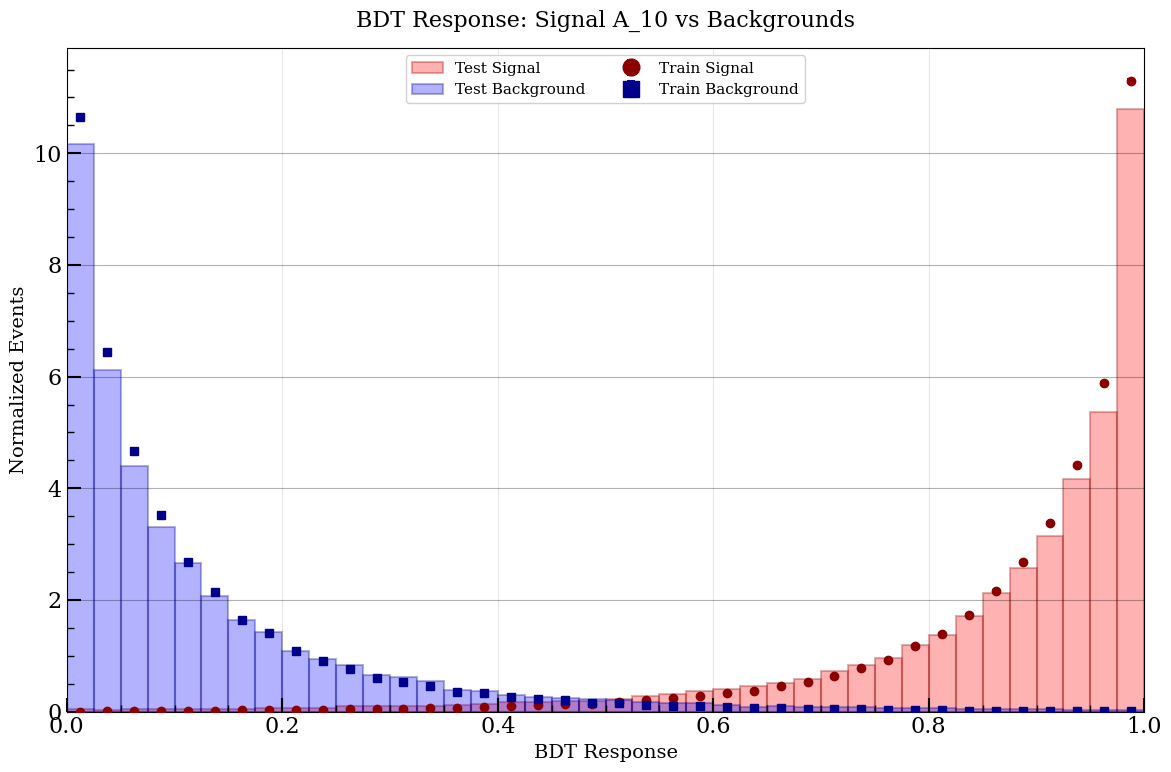

In [ ]:
train_scores = model.predict_proba(X_train)[:, 1]
test_scores = model.predict_proba(X_test)[:, 1]


# Usage
fig, ax = plot_bdt_response_advanced(
    y_train, train_scores, 
    y_test, test_scores,
    bins=40,
    weights_train=weights_train,
    weights_test=weights_test,
    title='BDT Response: Signal A_10 vs Backgrounds',
    log_scale=False
)
plt.savefig('ALP_ANALYSIS/bdt_response.png', dpi=300, bbox_inches='tight')
plt.show()